# Optimización Logística con Análisis Topológico de Datos

Xavier Lago Hicks | A01403177

Santiago Tolosa Torres | A00838869

## 1. Preparación y limpieza de datos

### 1.1 Carga del Excel e imports


In [ ]:
##Instalación de librerías TDA

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
import networkx as nx
import pulp

try:
    from ripser import ripser
    from persim import plot_diagrams
    RIPSER_DISPONIBLE = True

except ImportError:
    RIPSER_DISPONIBLE = False

⚠ ripser no instalado — se usará aproximación manual
  Para instalar: !pip install ripser persim
Librerías cargadas correctamente.


In [ ]:
##Carga del Excel
archivo = "Bajada Interplanta 2026.xlsx"
df = pd.read_excel(archivo)

print("Tamaño de la base:", df.shape)
print("\nPrimeras filas:")
display(df.head())
print("\nColumnas:")
print(df.columns.tolist())

Tamaño de la base: (64532, 47)

Primeras filas:


,C_SOCIEDAD,REMITO,FECHA_ALTA_REMITO,MESREMITO,DIAREMITO,FECHA_SOLICITADA,C_ID_ORDEN_CABECERA,REF_PEDIDO,DOCUMENTO_REFERENCIA,C_POSICION_ORDEN,...,N_PESO_BRUTO,D_CARACT_PRODUCTO,D_PRODUCTO,T_USUARIO_ALTA,C_ID_SOLICITUD,SOLICITUD,ID_1330,ALMACEN_CD,ANDEN_CD,GRUISTA_CD
0,TM01,T00002615415,20-01-2026 17:13,1,20,21-01-2026 00:00,23496415,DEC3_CHU-260330-17,PROGRAMA,1,...,19.490,NaN,MP546450,oaiusr,11946545.0,CON SOLICITUD,814959820.0,Despacho,ZN CARGA A4,TermxIOTSvcUser
1,TM01,T00002615415,20-01-2026 17:13,1,20,25-01-2026 11:20,23496859,DEC3_CHU,DESALOJO,1,...,19.700,NaN,MP535351,oaiusr,11947462.0,CON SOLICITUD,814959820.0,Despacho,ZN CARGA A4,TermxIOTSvcUser
2,TM01,T00002613552,17-01-2026 11:17,1,17,17-01-2026 05:40,23470240,DEC3_CHU,DESALOJO,1,...,19.290,NaN,MP559762,oaiusr,11915749.0,CON SOLICITUD,813868447.0,Playa Sur,Anden 8 Playa Sur,terncalogisticabot
3,TM01,T00002613552,17-01-2026 11:17,1,17,25-01-2026 22:41,23479491,DEC3_CHU,DESALOJO,1,...,19.064,NaN,MP515815,oaiusr,11926733.0,CON SOLICITUD,813868447.0,Playa Sur,Anden 8 Playa Sur,terncalogisticabot
4,TM01,T00002610186,2026-11-01 10:36:00,1,11,2026-05-01 17:57:00,23388215,SL1_CSIN-260101-1,PROGRAMA,1,...,19.005,MP501067,ROLLO CALIENTE CON SKIN PASS SAE J403 \ 1008 P...,oaiusr,11837612.0,CON SOLICITUD,811778227.0,Playa Sur,Anden 4 Playa Sur,terncalogisticabot



Columnas:
['C_SOCIEDAD', 'REMITO', 'FECHA_ALTA_REMITO', 'MESREMITO', 'DIAREMITO', 'FECHA_SOLICITADA', 'C_ID_ORDEN_CABECERA', 'REF_PEDIDO', 'DOCUMENTO_REFERENCIA', 'C_POSICION_ORDEN', 'FECHA_ALTA_ORDEN', 'FECHA_ALTA_VIAJE', 'FECHA_SALIDA_ORIGEN', 'FECHA_LLEGADA_DESTINO', 'FECHA_PRIMER_PROGRAMACION', 'TIPO_SERVICIO', 'D_MEDIO_TRANSPORTE', 'ID_TIPO_CAMION', 'NOMBRE_TIPO_CAMION', 'TIPO_ORDEN', 'C_ID_VIAJE', 'N_NRO_PERMISO', 'TIPO_PERMISO', 'TIPOTRANSPORTE', 'PLANTA_ORIGEN', 'ALMACENPROGRAMADO', 'C_CLIENTE_DESTINO', 'DESTINO', 'ALMACEN_DESTINO', 'C_ID_TIPO_ESTRATEGIA', 'C_CLAVE', 'C_MATERIAL', 'N_ESPESOR', 'N_ANCHO', 'C_UMED', 'N_CANTIDAD', 'N_PESO_NETO', 'N_PESO_BRUTO', 'D_CARACT_PRODUCTO', 'D_PRODUCTO', 'T_USUARIO_ALTA', 'C_ID_SOLICITUD', 'SOLICITUD', 'ID_1330', 'ALMACEN_CD', 'ANDEN_CD', 'GRUISTA_CD']


### 1.2 Limpieza de columnas

Se normalizan los nombres de columnas para evitar errores de referencia. Se convierten fechas y valores numéricos a sus tipos correctos.

In [ ]:
##Normalizar nombres de columnas
df_limpio = df.copy()
df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
    .str.replace("Í", "I")
    .str.replace("Á", "A")
    .str.replace("É", "E")
    .str.replace("Ó", "O")
    .str.replace("Ú", "U")
)
print(df_limpio.columns.tolist())

['C_SOCIEDAD', 'REMITO', 'FECHA_ALTA_REMITO', 'MESREMITO', 'DIAREMITO', 'FECHA_SOLICITADA', 'C_ID_ORDEN_CABECERA', 'REF_PEDIDO', 'DOCUMENTO_REFERENCIA', 'C_POSICION_ORDEN', 'FECHA_ALTA_ORDEN', 'FECHA_ALTA_VIAJE', 'FECHA_SALIDA_ORIGEN', 'FECHA_LLEGADA_DESTINO', 'FECHA_PRIMER_PROGRAMACION', 'TIPO_SERVICIO', 'D_MEDIO_TRANSPORTE', 'ID_TIPO_CAMION', 'NOMBRE_TIPO_CAMION', 'TIPO_ORDEN', 'C_ID_VIAJE', 'N_NRO_PERMISO', 'TIPO_PERMISO', 'TIPOTRANSPORTE', 'PLANTA_ORIGEN', 'ALMACENPROGRAMADO', 'C_CLIENTE_DESTINO', 'DESTINO', 'ALMACEN_DESTINO', 'C_ID_TIPO_ESTRATEGIA', 'C_CLAVE', 'C_MATERIAL', 'N_ESPESOR', 'N_ANCHO', 'C_UMED', 'N_CANTIDAD', 'N_PESO_NETO', 'N_PESO_BRUTO', 'D_CARACT_PRODUCTO', 'D_PRODUCTO', 'T_USUARIO_ALTA', 'C_ID_SOLICITUD', 'SOLICITUD', 'ID_1330', 'ALMACEN_CD', 'ANDEN_CD', 'GRUISTA_CD']


In [ ]:
##Convertir columnas de fechas
columnas_fechas = [
    "FECHA_ALTA_REMITO", "FECHA_SOLICITADA", "FECHA_ALTA_ORDEN",
    "FECHA_ALTA_VIAJE", "FECHA_SALIDA_ORIGEN", "FECHA_LLEGADA_DESTINO",
    "FECHA_PRIMER_PROGRAMACION"
]
columnas_fechas = [col for col in columnas_fechas if col in df_limpio.columns]

for col in columnas_fechas:
    df_limpio[col] = pd.to_datetime(df_limpio[col], errors="coerce", dayfirst=True)

print(df_limpio[columnas_fechas].dtypes)

FECHA_ALTA_REMITO            datetime64[ns]
FECHA_SOLICITADA             datetime64[ns]
FECHA_ALTA_ORDEN             datetime64[ns]
FECHA_ALTA_VIAJE             datetime64[ns]
FECHA_SALIDA_ORIGEN          datetime64[ns]
FECHA_LLEGADA_DESTINO        datetime64[ns]
FECHA_PRIMER_PROGRAMACION    datetime64[ns]
dtype: object


In [ ]:
##Convertir columnas numéricas
columnas_numericas = [
    "N_ESPESOR", "N_ANCHO", "N_CANTIDAD", "N_PESO_NETO", "N_PESO_BRUTO",
    "ID_TIPO_CAMION", "C_ID_VIAJE", "C_ID_ORDEN_CABECERA", "C_POSICION_ORDEN"
]
for col in columnas_numericas:
    if col in df_limpio.columns:
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

##Limpiar columnas de texto
columnas_texto = df_limpio.select_dtypes(include=["object"]).columns
for col in columnas_texto:
    df_limpio[col] = (
        df_limpio[col]
        .astype(str).str.strip().str.upper()
        .replace("NAN", np.nan).replace("NONE", np.nan).replace("", np.nan)
    )

Limpieza de texto y numéricos completada.


### 1.3 Validación de nulos y duplicados

Se identifican las columnas con más valores faltantes y se eliminan duplicados exactos.

In [ ]:
##Valores nulos por columna
nulos = df_limpio.isnull().sum().sort_values(ascending=False)
print("Valores nulos por columna:")
print(nulos[nulos > 0])

##Eliminar duplicados exactos
antes = df_limpio.shape[0]
df_limpio = df_limpio.drop_duplicates()
print(f"\nFilas antes: {antes} | Después de quitar duplicados: {df_limpio.shape[0]}")

Valores nulos por columna:
C_CLIENTE_DESTINO            62325
C_ID_SOLICITUD               28984
DOCUMENTO_REFERENCIA         28654
REF_PEDIDO                   26777
D_CARACT_PRODUCTO            16618
ANDEN_CD                     15348
ALMACEN_DESTINO               4059
FECHA_PRIMER_PROGRAMACION     3599
FECHA_LLEGADA_DESTINO         1600
FECHA_SALIDA_ORIGEN           1147
N_ESPESOR                      371
N_ANCHO                        371
ID_1330                          3
ALMACEN_CD                       3
GRUISTA_CD                       3
D_PRODUCTO                       1
dtype: int64

Filas antes: 64532 | Después de quitar duplicados: 64531


### 1.4 Construcción de variables logísticas

Se calculan variables derivadas clave: tiempos de tránsito, retrasos, banderas de cumplimiento y el identificador de circuito origen-destino (`CIRCUITO_OD`).

In [ ]:
##Variables de calidad y tiempo
df_limpio["ERROR_PESO"] = np.where(df_limpio["N_PESO_BRUTO"] < df_limpio["N_PESO_NETO"], 1, 0)
df_limpio["ERROR_CANTIDAD"] = np.where(df_limpio["N_CANTIDAD"] < 0, 1, 0)

df_limpio["TIEMPO_TRANSITO_HRS"] = (
    df_limpio["FECHA_LLEGADA_DESTINO"] - df_limpio["FECHA_SALIDA_ORIGEN"]
).dt.total_seconds() / 3600

df_limpio["RETRASO_HRS"] = (
    df_limpio["FECHA_LLEGADA_DESTINO"] - df_limpio["FECHA_SOLICITADA"]
).dt.total_seconds() / 3600

df_limpio["ERROR_TIEMPO_TRANSITO"] = np.where(
    (df_limpio["TIEMPO_TRANSITO_HRS"].isna()) |
    (df_limpio["TIEMPO_TRANSITO_HRS"] < 0) |
    (df_limpio["TIEMPO_TRANSITO_HRS"] > 168),
    1, 0
)

df_limpio["CUMPLE_FECHA"] = np.where(
    df_limpio["RETRASO_HRS"].isna(), np.nan,
    np.where(df_limpio["RETRASO_HRS"] <= 0, 1, 0)
)

##Variables temporales y de circuito
df_limpio["ANIO"] = df_limpio["FECHA_SALIDA_ORIGEN"].dt.year
df_limpio["MES"]  = df_limpio["FECHA_SALIDA_ORIGEN"].dt.month
df_limpio["CIRCUITO_OD"] = (
    df_limpio["PLANTA_ORIGEN"].astype(str) + " -> " + df_limpio["DESTINO"].astype(str)
)

df_limpio["PESO_NETO_TON"]  = df_limpio["N_PESO_NETO"]
df_limpio["PESO_BRUTO_TON"] = df_limpio["N_PESO_BRUTO"]

print("Variables logísticas construidas. Shape:", df_limpio.shape)

Variables logísticas construidas. Shape: (64531, 58)


In [ ]:
##Base limpia válida para análisis
df_analisis = df_limpio[
    (df_limpio["PLANTA_ORIGEN"].notnull()) &
    (df_limpio["DESTINO"].notnull()) &
    (df_limpio["C_MATERIAL"].notnull()) &
    (df_limpio["N_PESO_NETO"].notnull()) &
    (df_limpio["N_PESO_NETO"] > 0) &
    (df_limpio["ERROR_TIEMPO_TRANSITO"] == 0) &
    (df_limpio["ERROR_PESO"] == 0) &
    (df_limpio["ERROR_CANTIDAD"] == 0)
].copy()

df_analisis["RETRASO_POSITIVO_HRS"] = df_analisis["RETRASO_HRS"].clip(lower=0)

print("Base original:", df_limpio.shape)
print("Base válida para análisis:", df_analisis.shape)

Base original: (64531, 58)
Base válida para análisis: (42107, 59)


## 3. Resumen de circuitos logísticos

### 3.1 Demanda por ruta y 3.2 Tiempo promedio

In [ ]:
##Resumen por circuito
resumen_circuitos = df_analisis.groupby("CIRCUITO_OD").agg(
    TOTAL_VIAJES=("C_ID_VIAJE", "nunique"),
    TOTAL_MATERIALES=("C_MATERIAL", "nunique"),
    PESO_NETO_TOTAL_TON=("PESO_NETO_TON", "sum"),
    PESO_PROMEDIO_TON=("PESO_NETO_TON", "mean"),
    TIEMPO_TRANSITO_PROM_HRS=("TIEMPO_TRANSITO_HRS", "mean"),
    TIEMPO_TRANSITO_STD_HRS=("TIEMPO_TRANSITO_HRS", "std"),
    RETRASO_PROM_HRS=("RETRASO_POSITIVO_HRS", "mean"),
    CUMPLIMIENTO_PROM=("CUMPLE_FECHA", "mean")
).reset_index()

resumen_circuitos["CUMPLIMIENTO_%"] = resumen_circuitos["CUMPLIMIENTO_PROM"] * 100

# Filtrar por mínimo de viajes históricos
minimo_viajes = 30
resumen_circuitos = resumen_circuitos[
    resumen_circuitos["TOTAL_VIAJES"] >= minimo_viajes
].copy()

print(f"Circuitos con suficiente historial (>= {minimo_viajes} viajes):", resumen_circuitos.shape[0])
display(resumen_circuitos.head())

Circuitos con suficiente historial (>= 30 viajes): 13


,CIRCUITO_OD,TOTAL_VIAJES,TOTAL_MATERIALES,PESO_NETO_TOTAL_TON,PESO_PROMEDIO_TON,TIEMPO_TRANSITO_PROM_HRS,TIEMPO_TRANSITO_STD_HRS,RETRASO_PROM_HRS,CUMPLIMIENTO_PROM,CUMPLIMIENTO_%
0,PESQUERÍA -> BODEGA ACEROMEX,105,308,2980.858,9.646790,18.431230,25.914387,335.323894,0.126214,12.621359
1,PESQUERÍA -> BODEGA DEL TORO,1229,2873,39311.618,13.593229,8.690560,12.764404,241.373657,0.160788,16.078838
2,PESQUERÍA -> BODEGA FOREMEX AGUA FRIA,56,58,1396.470,24.077069,9.293391,6.024125,224.631897,0.034483,3.448276
6,PESQUERÍA -> CHURUBUSCO,8614,12516,250820.095,19.992037,4.457077,8.914511,428.367889,0.519209,51.920931
8,PESQUERÍA -> CS INDUSTRIAL NOGALAR,451,794,12697.498,15.991811,5.115428,9.145694,372.311335,0.430730,43.073048


### 3.3 Capacidad estimada y 3.4 Score de criticidad

El **Score de Criticidad** combina el impacto operativo (volumen, viajes, materiales) con el riesgo logístico (incumplimiento, retraso, variabilidad). Es la métrica que el modelo base usará para priorizar rutas.

In [ ]:
##Función de normalización 0-1
def normalizar_0_1(serie):
    minimo, maximo = serie.min(), serie.max()
    if maximo == minimo:
        return serie * 0
    return (serie - minimo) / (maximo - minimo)

# Score de impacto operativo
resumen_circuitos["SCORE_VOLUMEN"]    = normalizar_0_1(resumen_circuitos["PESO_NETO_TOTAL_TON"].fillna(0))
resumen_circuitos["SCORE_VIAJES"]     = normalizar_0_1(resumen_circuitos["TOTAL_VIAJES"].fillna(0))
resumen_circuitos["SCORE_MATERIALES"] = normalizar_0_1(resumen_circuitos["TOTAL_MATERIALES"].fillna(0))

resumen_circuitos["SCORE_IMPACTO"] = (
    resumen_circuitos["SCORE_VOLUMEN"]    * 0.45 +
    resumen_circuitos["SCORE_VIAJES"]     * 0.35 +
    resumen_circuitos["SCORE_MATERIALES"] * 0.20
)

# Score de riesgo logístico
resumen_circuitos["SCORE_RETRASO"]       = normalizar_0_1(resumen_circuitos["RETRASO_PROM_HRS"].fillna(0))
resumen_circuitos["SCORE_VARIABILIDAD"]  = normalizar_0_1(resumen_circuitos["TIEMPO_TRANSITO_STD_HRS"].fillna(0))
resumen_circuitos["SCORE_INCUMPLIMIENTO"] = 1 - normalizar_0_1(resumen_circuitos["CUMPLIMIENTO_%"].fillna(0))

resumen_circuitos["SCORE_RIESGO"] = (
    resumen_circuitos["SCORE_INCUMPLIMIENTO"] * 0.40 +
    resumen_circuitos["SCORE_RETRASO"]        * 0.35 +
    resumen_circuitos["SCORE_VARIABILIDAD"]   * 0.25
)

# SCORE_CRITICIDAD combinado
resumen_circuitos["SCORE_CRITICIDAD"] = (
    resumen_circuitos["SCORE_IMPACTO"] * 0.60 +
    resumen_circuitos["SCORE_RIESGO"]  * 0.40
)

ranking_circuitos_criticos = resumen_circuitos.sort_values("SCORE_CRITICIDAD", ascending=False)
ranking_circuitos_criticos["NIVEL_CRITICIDAD"] = pd.qcut(
    ranking_circuitos_criticos["SCORE_CRITICIDAD"],
    q=3, labels=["BAJA", "MEDIA", "ALTA"], duplicates="drop"
)

display(ranking_circuitos_criticos[[
    "CIRCUITO_OD", "TOTAL_VIAJES", "PESO_NETO_TOTAL_TON",
    "RETRASO_PROM_HRS", "CUMPLIMIENTO_%",
    "SCORE_IMPACTO", "SCORE_RIESGO", "SCORE_CRITICIDAD", "NIVEL_CRITICIDAD"
]].head(15))

,CIRCUITO_OD,TOTAL_VIAJES,PESO_NETO_TOTAL_TON,RETRASO_PROM_HRS,CUMPLIMIENTO_%,SCORE_IMPACTO,SCORE_RIESGO,SCORE_CRITICIDAD,NIVEL_CRITICIDAD
6,PESQUERÍA -> CHURUBUSCO,8614,250820.095,428.367889,51.920931,1.000000,0.247642,0.699057,ALTA
15,PESQUERÍA -> JUVENTUD,2741,91216.975,498.827754,53.975014,0.383612,0.299455,0.349949,ALTA
22,PESQUERÍA -> UNIVERSIDAD,2632,87582.075,425.334723,46.646290,0.354182,0.297999,0.331709,ALTA
17,PESQUERÍA -> PLANOS GUERRERO,3062,91018.046,308.110943,45.148969,0.367628,0.190033,0.296590,ALTA
0,PESQUERÍA -> BODEGA ACEROMEX,105,2980.858,335.323894,12.621359,0.008876,0.682041,0.278142,ALTA
1,PESQUERÍA -> BODEGA DEL TORO,1229,39311.618,241.373657,16.078838,0.161569,0.400289,0.257057,MEDIA
10,PESQUERÍA -> CSI APODACA,900,28959.560,536.946305,43.013875,0.132969,0.430245,0.251880,MEDIA
9,PESQUERÍA -> CSC APODACA,144,4723.424,589.827329,43.585237,0.017805,0.522477,0.219674,MEDIA
16,PESQUERÍA -> MONCLOVA,310,9929.994,304.886072,11.002786,0.036379,0.488246,0.217126,BAJA
13,PESQUERÍA -> GUERRERO,1001,25207.510,569.011843,48.943662,0.103472,0.380105,0.214125,BAJA


## 4. Modelo base MILP


La función objetivo minimiza el volumen no atendido, penalizando más las rutas con mayor criticidad:

```
min Z = Σ (1 + criticidad[r]) * vol_no_atendido[r] + Σ penalización * x[r] * tiempo[r]
```

Este modelo **no considera** la estructura de la red ni las relaciones entre rutas.

### 4.1 Variables de decisión y parámetros operativos

### 4.0 Justificación de la demanda objetivo

La demanda objetivo se calcula como **demanda promedio calendario**, dividiendo las toneladas totales de cada ruta entre todos los días del periodo analizado.

In [ ]:
##Preparar datos para el modelo base
top_n_rutas = 50
rutas_base = ranking_circuitos_criticos.head(top_n_rutas).copy()

# Demanda conservadora por circuito
df_lno_base = df_analisis.copy()
df_lno_base["FECHA_DIA"] = pd.to_datetime(df_lno_base["FECHA_SALIDA_ORIGEN"]).dt.date

# Toneladas movidas por ruta y día con operación
demanda_diaria = df_lno_base.groupby(["CIRCUITO_OD", "FECHA_DIA"]).agg(
    TON_DIA=("PESO_NETO_TON", "sum"),
    VIAJES_DIA=("C_ID_VIAJE", "nunique")
).reset_index()

# Días calendario del periodo completo analizado
dias_periodo = (
    pd.to_datetime(df_lno_base["FECHA_DIA"]).max()
    - pd.to_datetime(df_lno_base["FECHA_DIA"]).min()
).days + 1

# Parámetros de demanda por ruta
param_demanda = demanda_diaria.groupby("CIRCUITO_OD").agg(
    TON_TOTAL_PERIODO=("TON_DIA", "sum"),
    DIAS_CON_VIAJE=("FECHA_DIA", "nunique"),
    DEMANDA_PROM_DIA_ACTIVO=("TON_DIA", "mean"),
    DEMANDA_MAX_DIA_TON=("TON_DIA", "max"),
    VIAJES_PROM_DIA=("VIAJES_DIA", "mean"),
    VIAJES_MAX_DIA=("VIAJES_DIA", "max")
).reset_index()

param_demanda["DIAS_PERIODO"] = dias_periodo

# Demanda conservadora:
# toneladas totales del periodo / días calendario del periodo
param_demanda["DEMANDA_PROM_DIA_CALENDARIO"] = (
    param_demanda["TON_TOTAL_PERIODO"] / param_demanda["DIAS_PERIODO"]
)

# Validación: compara demanda por día activo vs demanda calendario
param_demanda["FACTOR_INFLACION_DEMANDA"] = (
    param_demanda["DEMANDA_PROM_DIA_ACTIVO"] /
    param_demanda["DEMANDA_PROM_DIA_CALENDARIO"]
)

display(
    param_demanda[[
        "CIRCUITO_OD",
        "DIAS_CON_VIAJE",
        "DIAS_PERIODO",
        "TON_TOTAL_PERIODO",
        "DEMANDA_PROM_DIA_CALENDARIO",
        "DEMANDA_PROM_DIA_ACTIVO",
        "FACTOR_INFLACION_DEMANDA"
    ]].sort_values("FACTOR_INFLACION_DEMANDA", ascending=False)
)

rutas_base = rutas_base.merge(param_demanda, on="CIRCUITO_OD", how="left")
rutas_base = rutas_base[
    rutas_base["CIRCUITO_OD"].notnull() &
    rutas_base["PESO_PROMEDIO_TON"].notnull() &
    rutas_base["TIEMPO_TRANSITO_PROM_HRS"].notnull() &
    rutas_base["SCORE_CRITICIDAD"].notnull() &
    rutas_base["DEMANDA_PROM_DIA_CALENDARIO"].notnull()
].copy()
rutas_base = rutas_base[
    (rutas_base["PESO_PROMEDIO_TON"] > 0) &
    (rutas_base["TIEMPO_TRANSITO_PROM_HRS"] > 0) &
    (rutas_base["DEMANDA_PROM_DIA_CALENDARIO"] > 0)
].copy()

##Parámetros operativos
horizonte_dias         = 1
camiones_disponibles   = 30
horas_por_camion_dia   = 20
tiempo_carga_descarga_hrs = 2
horas_camion_disponibles = camiones_disponibles * horas_por_camion_dia * horizonte_dias

rutas_base["DEMANDA_OBJETIVO_TON"] = (
    rutas_base["DEMANDA_PROM_DIA_CALENDARIO"] * horizonte_dias
)
rutas_base["CAPACIDAD_ESTIMADA_VIAJE_TON"] = rutas_base["PESO_PROMEDIO_TON"]
rutas_base["TIEMPO_TOTAL_VIAJE_HRS"]       = rutas_base["TIEMPO_TRANSITO_PROM_HRS"] * 2 + tiempo_carga_descarga_hrs
rutas_base["MAX_VIAJES_RUTA"] = np.ceil(
    rutas_base["VIAJES_MAX_DIA"].fillna(rutas_base["VIAJES_PROM_DIA"]) * 1.20
).astype(int).clip(lower=1)
rutas_base["VIAJES_NECESARIOS"] = np.ceil(
    rutas_base["DEMANDA_OBJETIVO_TON"] / rutas_base["CAPACIDAD_ESTIMADA_VIAJE_TON"]
).astype(int)

print(f"Horas-camión disponibles: {horas_camion_disponibles}")
print(f"Rutas válidas para modelo base: {len(rutas_base)}")
display(rutas_base[[
    "CIRCUITO_OD", "DEMANDA_OBJETIVO_TON", "CAPACIDAD_ESTIMADA_VIAJE_TON",
    "TIEMPO_TOTAL_VIAJE_HRS", "MAX_VIAJES_RUTA", "VIAJES_NECESARIOS", "SCORE_CRITICIDAD"
]].head(10))

,CIRCUITO_OD,DIAS_CON_VIAJE,DIAS_PERIODO,TON_TOTAL_PERIODO,DEMANDA_PROM_DIA_CALENDARIO,DEMANDA_PROM_DIA_ACTIVO,FACTOR_INFLACION_DEMANDA
3,PESQUERÍA -> BODEGA SMART LOGISTIC,1,339,8.260,0.024366,8.260000,339.000000
18,PESQUERÍA -> PLESA ANAHUAC,1,339,23.120,0.068201,23.120000,339.000000
21,PESQUERÍA -> THYSSENKRUPP SLP,1,339,14.710,0.043392,14.710000,339.000000
19,PESQUERÍA -> POSCO MPPC,2,339,36.430,0.107463,18.215000,169.500000
14,PESQUERÍA -> INGENIERIA Y MAQUINARIA DE GUADALUPE,2,339,38.630,0.113953,19.315000,169.500000
4,PESQUERÍA -> BODEGA SMART LOGISTICS PESQUERIA,2,339,57.474,0.169540,28.737000,169.500000
20,PESQUERÍA -> PROMETAL,3,339,153.320,0.452271,51.106667,113.000000
12,PESQUERÍA -> EDIFICIOS METÁLICOS,4,339,138.441,0.408381,34.610250,84.750000
7,PESQUERÍA -> CONTROLADORA MABE SA DE CV,7,339,105.248,0.310466,15.035429,48.428571
2,PESQUERÍA -> BODEGA FOREMEX AGUA FRIA,8,339,1396.470,4.119381,174.558750,42.375000


Horas-camión disponibles: 600
Rutas válidas para modelo base: 13


,CIRCUITO_OD,DEMANDA_OBJETIVO_TON,CAPACIDAD_ESTIMADA_VIAJE_TON,TIEMPO_TOTAL_VIAJE_HRS,MAX_VIAJES_RUTA,VIAJES_NECESARIOS,SCORE_CRITICIDAD
0,PESQUERÍA -> CHURUBUSCO,739.882286,19.992037,10.914153,152,38,0.699057
1,PESQUERÍA -> JUVENTUD,269.076622,12.949599,12.988387,69,21,0.349949
2,PESQUERÍA -> UNIVERSIDAD,258.354204,14.872147,12.846380,52,18,0.331709
3,PESQUERÍA -> PLANOS GUERRERO,268.489811,17.383126,10.938796,65,16,0.296590
4,PESQUERÍA -> BODEGA ACEROMEX,8.793091,9.646790,38.862460,21,1,0.278142
5,PESQUERÍA -> BODEGA DEL TORO,115.963475,13.593229,19.381120,74,9,0.257057
6,PESQUERÍA -> CSI APODACA,85.426431,9.344808,11.015241,24,10,0.251880
7,PESQUERÍA -> CSC APODACA,13.933404,8.301272,11.936497,6,2,0.219674
8,PESQUERÍA -> MONCLOVA,29.292018,13.830075,26.096425,12,3,0.217126
9,PESQUERÍA -> GUERRERO,74.358437,17.751768,9.686784,35,5,0.214125


### 4.2 Función objetivo y 4.3 Restricciones operativas

In [ ]:
# ── Construcción del Modelo Base MILP ──
modelo_base = pulp.LpProblem("Modelo_Base_Rutas_Criticas", pulp.LpMinimize)

rutas_b     = rutas_base["CIRCUITO_OD"].tolist()
demanda_b   = dict(zip(rutas_base["CIRCUITO_OD"], rutas_base["DEMANDA_OBJETIVO_TON"]))
capacidad_b = dict(zip(rutas_base["CIRCUITO_OD"], rutas_base["CAPACIDAD_ESTIMADA_VIAJE_TON"]))
tiempo_b    = dict(zip(rutas_base["CIRCUITO_OD"], rutas_base["TIEMPO_TOTAL_VIAJE_HRS"]))
crit_b      = dict(zip(rutas_base["CIRCUITO_OD"], rutas_base["SCORE_CRITICIDAD"]))
max_v_b     = dict(zip(rutas_base["CIRCUITO_OD"], rutas_base["MAX_VIAJES_RUTA"]))
viajes_nec_b = dict(zip(rutas_base["CIRCUITO_OD"], rutas_base["VIAJES_NECESARIOS"]))

# Variables de decisión
xb   = pulp.LpVariable.dicts("Viajes_Base",     rutas_b, lowBound=0, cat="Integer")
vab  = pulp.LpVariable.dicts("VolAtendido_Base", rutas_b, lowBound=0, cat="Continuous")
vnab = pulp.LpVariable.dicts("VolNoAtend_Base",  rutas_b, lowBound=0, cat="Continuous")
yb   = pulp.LpVariable.dicts("Activa_Base",      rutas_b, lowBound=0, upBound=1, cat="Binary")

penalizacion_viaje_base = 0.01

# Función objetivo
modelo_base += pulp.lpSum([
    (1 + crit_b[r]) * vnab[r] + penalizacion_viaje_base * xb[r] * tiempo_b[r]
    for r in rutas_b
])

# Restricciones operativas
for r in rutas_b:
    modelo_base += vab[r] <= demanda_b[r]
    modelo_base += vab[r] <= xb[r] * capacidad_b[r]
    modelo_base += vab[r] + vnab[r] == demanda_b[r]
    modelo_base += xb[r] <= max_v_b[r]
    modelo_base += xb[r] <= viajes_nec_b[r] * yb[r]
    modelo_base += xb[r] >= yb[r]

modelo_base += pulp.lpSum([xb[r] * tiempo_b[r] for r in rutas_b]) <= horas_camion_disponibles

modelo_base.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"Estatus modelo base: {pulp.LpStatus[modelo_base.status]}")
print(f"Valor objetivo:      {pulp.value(modelo_base.objective):.4f}")

Estatus modelo base: Optimal
Valor objetivo:      1157.4215


### 4.4 Resultados del modelo base

In [ ]:
# ── Resultados del modelo base ──
resultados_base = []
for r in rutas_b:
    resultados_base.append({
        "CIRCUITO_OD":                   r,
        "RUTA_ACTIVA":                   int(yb[r].value() or 0),
        "VIAJES_ASIGNADOS":              int(xb[r].value() or 0),
        "DEMANDA_OBJETIVO_TON":          demanda_b[r],
        "VOLUMEN_ATENDIDO_TON":          vab[r].value() or 0.0,
        "VOLUMEN_NO_ATENDIDO_TON":       vnab[r].value() or 0.0,
        "HORAS_CAMION_USADAS":           (xb[r].value() or 0) * tiempo_b[r],
        "SCORE_CRITICIDAD":              crit_b[r],
    })

solucion_base = pd.DataFrame(resultados_base)
solucion_base["PORCENTAJE_ATENDIDO"] = (
    solucion_base["VOLUMEN_ATENDIDO_TON"] / solucion_base["DEMANDA_OBJETIVO_TON"]
) * 100
solucion_base = solucion_base.sort_values(
    by=["RUTA_ACTIVA", "SCORE_CRITICIDAD"], ascending=[False, False]
)

# Guardar métricas para comparación posterior
resumen_base = {
    "MODELO":                    "BASE",
    "DEMANDA_TOTAL_TON":         solucion_base["DEMANDA_OBJETIVO_TON"].sum(),
    "VOLUMEN_ATENDIDO_TON":      solucion_base["VOLUMEN_ATENDIDO_TON"].sum(),
    "VOLUMEN_NO_ATENDIDO_TON":   solucion_base["VOLUMEN_NO_ATENDIDO_TON"].sum(),
    "VIAJES_ASIGNADOS":          solucion_base["VIAJES_ASIGNADOS"].sum(),
    "RUTAS_ACTIVAS":             int(solucion_base["RUTA_ACTIVA"].sum()),
    "HORAS_CAMION_USADAS":       solucion_base["HORAS_CAMION_USADAS"].sum(),
}
resumen_base["PORCENTAJE_ATENDIDO"] = (
    resumen_base["VOLUMEN_ATENDIDO_TON"] / resumen_base["DEMANDA_TOTAL_TON"]
) * 100

print("\n─── RESUMEN MODELO BASE ───")
for k, v in resumen_base.items():
    print(f"  {k}: {round(v, 2) if isinstance(v, float) else v}")

display(solucion_base.head(20))


─── RESUMEN MODELO BASE ───
  MODELO: BASE
  DEMANDA_TOTAL_TON: 1942.24
  VOLUMEN_ATENDIDO_TON: 1053.71
  VOLUMEN_NO_ATENDIDO_TON: 888.53
  VIAJES_ASIGNADOS: 55
  RUTAS_ACTIVAS: 3
  HORAS_CAMION_USADAS: 596.97
  PORCENTAJE_ATENDIDO: 54.25


,CIRCUITO_OD,RUTA_ACTIVA,VIAJES_ASIGNADOS,DEMANDA_OBJETIVO_TON,VOLUMEN_ATENDIDO_TON,VOLUMEN_NO_ATENDIDO_TON,HORAS_CAMION_USADAS,SCORE_CRITICIDAD,PORCENTAJE_ATENDIDO
0,PESQUERÍA -> CHURUBUSCO,1,37,739.882286,739.705370,0.176921,403.823670,0.699057,99.976089
3,PESQUERÍA -> PLANOS GUERRERO,1,15,268.489811,260.746890,7.742926,164.081933,0.296590,97.116121
9,PESQUERÍA -> GUERRERO,1,3,74.358437,53.255303,21.103134,29.060352,0.214125,71.619719
1,PESQUERÍA -> JUVENTUD,0,0,269.076622,0.000000,269.076620,0.000000,0.349949,0.000000
2,PESQUERÍA -> UNIVERSIDAD,0,0,258.354204,0.000000,258.354200,0.000000,0.331709,0.000000
4,PESQUERÍA -> BODEGA ACEROMEX,0,0,8.793091,0.000000,8.793091,0.000000,0.278142,0.000000
5,PESQUERÍA -> BODEGA DEL TORO,0,0,115.963475,0.000000,115.963470,0.000000,0.257057,0.000000
6,PESQUERÍA -> CSI APODACA,0,0,85.426431,0.000000,85.426431,0.000000,0.251880,0.000000
7,PESQUERÍA -> CSC APODACA,0,0,13.933404,0.000000,13.933404,0.000000,0.219674,0.000000
8,PESQUERÍA -> MONCLOVA,0,0,29.292018,0.000000,29.292018,0.000000,0.217126,0.000000


## 6. Análisis topológico



El flujo del analisis topologico es:
1. Matriz de características por ruta → nube de puntos
2. Estandarización de variables
3. Single Linkage + Dendrograma → `COMUNIDAD_TOPOLOGICA`
4. Vietoris-Rips + Filtración → Persistencia H0 y H1
5. Diagrama de persistencia
6. Barcode de persistencia
7. Identificación de estructuras robustas

### 6.1 Matriz de características por ruta

Cada circuito se representa como un punto en un espacio de 4 dimensiones operativas. Si dos rutas están **cerca** en este espacio, tienen comportamiento similar. Si están **lejos**, sus perfiles logísticos son distintos.

In [ ]:
# ── Preparar datos para análisis topológico ──
top_n_rutas = 50
rutas_lno = ranking_circuitos_criticos.head(top_n_rutas).copy()
rutas_lno = rutas_lno.merge(param_demanda, on="CIRCUITO_OD", how="left")

rutas_lno = rutas_lno[
    rutas_lno["CIRCUITO_OD"].notnull() &
    rutas_lno["PESO_PROMEDIO_TON"].notnull() &
    rutas_lno["TIEMPO_TRANSITO_PROM_HRS"].notnull() &
    rutas_lno["SCORE_CRITICIDAD"].notnull() &
    rutas_lno["DEMANDA_PROM_DIA_CALENDARIO"].notnull()
].copy()
rutas_lno = rutas_lno[
    (rutas_lno["PESO_PROMEDIO_TON"] > 0) &
    (rutas_lno["TIEMPO_TRANSITO_PROM_HRS"] > 0) &
    (rutas_lno["DEMANDA_PROM_DIA_CALENDARIO"] > 0)
].copy()

# Variables operativas clave: las 4 que alimentan el modelo final
variables_base = [
    "DEMANDA_PROM_DIA_CALENDARIO",
    "PESO_PROMEDIO_TON",
    "TIEMPO_TRANSITO_PROM_HRS",
    "SCORE_CRITICIDAD",
]

# Construir columnas con nombres del modelo final
rutas_lno["DEMANDA_OBJETIVO_TON"] = (
    rutas_lno["DEMANDA_PROM_DIA_CALENDARIO"] * horizonte_dias
)
rutas_lno["CAPACIDAD_ESTIMADA_VIAJE_TON"] = rutas_lno["PESO_PROMEDIO_TON"]
rutas_lno["TIEMPO_TOTAL_VIAJE_HRS"]       = rutas_lno["TIEMPO_TRANSITO_PROM_HRS"] * 2 + tiempo_carga_descarga_hrs
rutas_lno["MAX_VIAJES_RUTA"] = np.ceil(
    rutas_lno["VIAJES_MAX_DIA"].fillna(rutas_lno["VIAJES_PROM_DIA"]) * 1.20
).astype(int).clip(lower=1)
rutas_lno["VIAJES_NECESARIOS"] = np.ceil(
    rutas_lno["DEMANDA_OBJETIVO_TON"] / rutas_lno["CAPACIDAD_ESTIMADA_VIAJE_TON"]
).astype(int)

df_modelo = rutas_lno.copy().reset_index(drop=True)

# Columnas para la matriz topológica
vars_topo = [
    "DEMANDA_OBJETIVO_TON",
    "CAPACIDAD_ESTIMADA_VIAJE_TON",
    "TIEMPO_TOTAL_VIAJE_HRS",
    "SCORE_CRITICIDAD",
]

df_modelo = df_modelo.dropna(subset=vars_topo).copy()
df_modelo = df_modelo[
    (df_modelo["DEMANDA_OBJETIVO_TON"] > 0) &
    (df_modelo["CAPACIDAD_ESTIMADA_VIAJE_TON"] > 0) &
    (df_modelo["TIEMPO_TOTAL_VIAJE_HRS"] > 0)
].copy().reset_index(drop=True)

print(f"Rutas válidas para análisis topológico: {len(df_modelo)}")
print(f"Variables: {vars_topo}")
display(df_modelo[vars_topo + ["CIRCUITO_OD"]].head())

Rutas válidas para análisis topológico: 13
Variables: ['DEMANDA_OBJETIVO_TON', 'CAPACIDAD_ESTIMADA_VIAJE_TON', 'TIEMPO_TOTAL_VIAJE_HRS', 'SCORE_CRITICIDAD']


,DEMANDA_OBJETIVO_TON,CAPACIDAD_ESTIMADA_VIAJE_TON,TIEMPO_TOTAL_VIAJE_HRS,SCORE_CRITICIDAD,CIRCUITO_OD
0,739.882286,19.992037,10.914153,0.699057,PESQUERÍA -> CHURUBUSCO
1,269.076622,12.949599,12.988387,0.349949,PESQUERÍA -> JUVENTUD
2,258.354204,14.872147,12.846380,0.331709,PESQUERÍA -> UNIVERSIDAD
3,268.489811,17.383126,10.938796,0.296590,PESQUERÍA -> PLANOS GUERRERO
4,8.793091,9.646790,38.862460,0.278142,PESQUERÍA -> BODEGA ACEROMEX


### 6.2 Estandarización de variables

In [ ]:
# ── Estandarización Min-Max ──
# Se usa MinMaxScaler para llevar todas las variables al rango [0, 1].
# Esto asegura que el SCORE_CRITICIDAD (0-1) no tenga menos peso que
# variables de mayor magnitud como DEMANDA_OBJETIVO_TON.
scaler_sl = MinMaxScaler()
X_sl = scaler_sl.fit_transform(df_modelo[vars_topo])

print("Matriz estandarizada:", X_sl.shape)
print("Rango por columna (min, max):")
for i, col in enumerate(vars_topo):
    print(f"  {col}: [{X_sl[:,i].min():.3f}, {X_sl[:,i].max():.3f}]")

Matriz estandarizada: (13, 4)
Rango por columna (min, max):
  DEMANDA_OBJETIVO_TON: [0.000, 1.000]
  CAPACIDAD_ESTIMADA_VIAJE_TON: [0.000, 1.000]
  TIEMPO_TOTAL_VIAJE_HRS: [0.000, 1.000]
  SCORE_CRITICIDAD: [0.000, 1.000]


### 6.3 Single Linkage + Dendrograma

El **Single Linkage** conecta los pares de rutas más cercanas primero, formando cadenas. Es ideal para detectar rutas que se encadenan operativamente. El dendrograma muestra visualmente cómo se fusionan los grupos conforme crece la distancia.

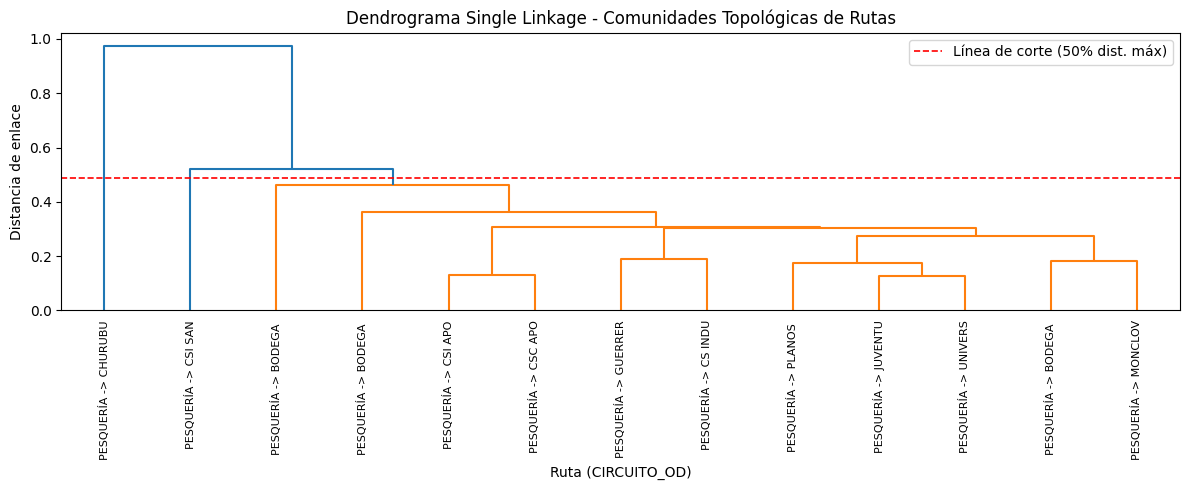

In [ ]:
# ── Single Linkage + Dendrograma ──
Z_sl = linkage(X_sl, method='single', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    Z_sl,
    ax=ax,
    labels=df_modelo['CIRCUITO_OD'].str[:20].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.5 * max(Z_sl[:, 2]),
)
ax.set_title('Dendrograma Single Linkage - Comunidades Topológicas de Rutas', fontsize=12)
ax.set_xlabel('Ruta (CIRCUITO_OD)')
ax.set_ylabel('Distancia de enlace')
ax.axhline(y=0.5 * max(Z_sl[:, 2]), color='red', linestyle='--', linewidth=1.2,
           label='Línea de corte (50% dist. máx)')
ax.legend()
plt.tight_layout()
plt.savefig('dendrograma_single_linkage.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.4 Comunidades topológicas

Con base en el dendrograma se asigna cada ruta a una **comunidad topológica**. Rutas dentro de la misma comunidad tienen perfiles operativos similares. El número de comunidades puede ajustarse según el dendrograma visual.

In [ ]:
# ── Crear COMUNIDAD_TOPOLOGICA ──
n_comunidades = 3  # Ajustar según el dendrograma visual

etiquetas_sl = fcluster(Z_sl, t=n_comunidades, criterion='maxclust') - 1
df_modelo['COMUNIDAD_TOPOLOGICA'] = etiquetas_sl

print(f'Comunidades topológicas (Single Linkage, k={n_comunidades}):')
for c in sorted(df_modelo['COMUNIDAD_TOPOLOGICA'].unique()):
    rutas_c = df_modelo[df_modelo['COMUNIDAD_TOPOLOGICA'] == c]['CIRCUITO_OD'].tolist()
    print(f'  Comunidad {c} ({len(rutas_c)} rutas): {rutas_c[:5]}...' if len(rutas_c) > 5 else f'  Comunidad {c}: {rutas_c}')

Comunidades topológicas (Single Linkage, k=3):
  Comunidad 0 (11 rutas): ['PESQUERÍA -> JUVENTUD', 'PESQUERÍA -> UNIVERSIDAD', 'PESQUERÍA -> PLANOS GUERRERO', 'PESQUERÍA -> BODEGA ACEROMEX', 'PESQUERÍA -> BODEGA DEL TORO']...
  Comunidad 1: ['PESQUERÍA -> CSI SAN LUIS POTOSÍ']
  Comunidad 2: ['PESQUERÍA -> CHURUBUSCO']


### 6.5 Vietoris-Rips + Filtración

El **complejo Vietoris-Rips** conecta pares de rutas cuya distancia es ≤ ε. Al aumentar ε (filtración), surgen y desaparecen componentes (H0) y ciclos (H1). Esto permite capturar cómo se estructura la red a diferentes escalas de similitud.

In [ ]:
# ── Vietoris-Rips + Filtración ──
X_vr = X_sl.copy()  # Misma matriz estandarizada

if RIPSER_DISPONIBLE:
    diagrams = ripser(X_vr, maxdim=1)['dgms']
    diag_H0 = diagrams[0]
    diag_H1 = diagrams[1]
    print(f'Persistencia H0: {len(diag_H0)} puntos (componentes conectadas)')
    print(f'Persistencia H1: {len(diag_H1)} puntos (ciclos)')
else:
    # Aproximación manual usando el dendrograma Single Linkage
    print('Usando aproximación manual de persistencia con dendrograma...')
    n = len(df_modelo)
    births_H0 = np.zeros(n)
    deaths_H0 = np.zeros(n)
    for row in Z_sl:
        left, right, height = int(row[0]), int(row[1]), row[2]
        if left < n and deaths_H0[left] == 0:
            deaths_H0[left] = height
        if right < n and deaths_H0[right] == 0:
            deaths_H0[right] = height
    deaths_H0[deaths_H0 == 0] = Z_sl[-1, 2]
    diag_H0 = np.column_stack([births_H0, deaths_H0])
    diag_H1 = np.empty((0, 2))
    diagrams = [diag_H0, diag_H1]
    print(f'Persistencia H0 aproximada: {len(diag_H0)} componentes')

persistencia_H0 = diag_H0[:, 1] - diag_H0[:, 0]
persistencia_H0 = persistencia_H0[np.isfinite(persistencia_H0)]
print(f'Top 5 persistencias H0: {np.sort(persistencia_H0)[::-1][:5].round(4)}')

Usando aproximación manual de persistencia con dendrograma...
Persistencia H0 aproximada: 13 componentes
Top 5 persistencias H0: [0.9738 0.5219 0.4637 0.3634 0.1904]


### 6.6 Diagrama de persistencia

El **diagrama de persistencia** muestra cada estructura topológica como un punto `(nacimiento, muerte)`. Los puntos alejados de la diagonal son estructuras robustas; los puntos cercanos a la diagonal son ruido.

### 6.7 Barcode de persistencia

El **barcode** representa las mismas estructuras como barras horizontales. Las barras más largas corresponden a las estructuras más persistentes (más robustas). Las barras cortas son ruido topológico.

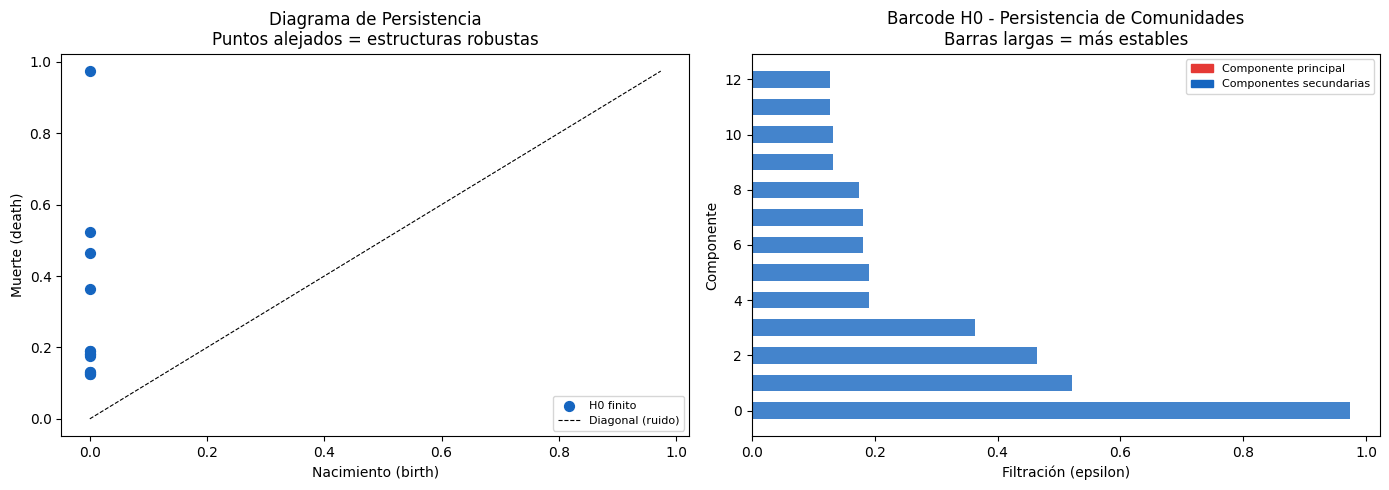

In [ ]:
# ── Diagrama de Persistencia y Barcode ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diagrama de persistencia
ax_pers = axes[0]
h0_finite = diag_H0[np.isfinite(diag_H0[:, 1])]
h0_inf    = diag_H0[~np.isfinite(diag_H0[:, 1])]

if len(h0_finite) > 0:
    ax_pers.scatter(h0_finite[:, 0], h0_finite[:, 1], c='#1565C0', s=50,
                    label='H0 finito', zorder=3)
if len(h0_inf) > 0:
    y_ref = h0_finite[:, 1].max() * 1.1 if len(h0_finite) > 0 else 1.0
    ax_pers.scatter(h0_inf[:, 0], [y_ref] * len(h0_inf), c='#E53935', s=70,
                    marker='^', label='H0 infinito (componente principal)', zorder=3)
if len(diag_H1) > 0 and np.any(np.isfinite(diag_H1[:, 1])):
    h1_f = diag_H1[np.isfinite(diag_H1[:, 1])]
    ax_pers.scatter(h1_f[:, 0], h1_f[:, 1], c='#FF6F00', s=40, marker='s',
                    label='H1 (ciclos)', zorder=3)
if len(h0_finite) > 0:
    vals = h0_finite.flatten()
    ax_pers.plot([vals.min(), vals.max()], [vals.min(), vals.max()],
                'k--', linewidth=0.8, label='Diagonal (ruido)')
ax_pers.set_xlabel('Nacimiento (birth)')
ax_pers.set_ylabel('Muerte (death)')
ax_pers.set_title('Diagrama de Persistencia\nPuntos alejados = estructuras robustas')
ax_pers.legend(fontsize=8)

# Barcode
ax_bar = axes[1]
orden_barras = np.argsort(-(diag_H0[:, 1] - diag_H0[:, 0]))
max_death = diag_H0[np.isfinite(diag_H0[:, 1]), 1].max() * 1.05 if len(h0_finite) > 0 else 1.0
for i_b, idx in enumerate(orden_barras):
    birth = diag_H0[idx, 0]
    death = diag_H0[idx, 1] if np.isfinite(diag_H0[idx, 1]) else max_death
    color = '#E53935' if not np.isfinite(diag_H0[idx, 1]) else '#1565C0'
    ax_bar.barh(i_b, death - birth, left=birth, height=0.6, color=color, alpha=0.8)
ax_bar.set_xlabel('Filtración (epsilon)')
ax_bar.set_ylabel('Componente')
ax_bar.set_title('Barcode H0 - Persistencia de Comunidades\nBarras largas = más estables')
ax_bar.legend(handles=[
    mpatches.Patch(color='#E53935', label='Componente principal'),
    mpatches.Patch(color='#1565C0', label='Componentes secundarias')
], fontsize=8)

plt.tight_layout()
plt.savefig('barcode_persistencia.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Construcción de scores

Con la información topológica se construyen dos scores que alimentan el modelo final:

- `SCORE_TOPOLOGICO`: importancia estructural de cada ruta dentro de la red
- `SCORE_CRITICIDAD_NORMALIZADO`: qué tan crítica es la ruta operativamente
- `SCORE_PRIORIDAD`: combinación de ambos scores

### 7.1 SCORE_TOPOLOGICO

Se construye combinando cuatro métricas topológicas:
1. **Persistencia H0 por comunidad**: comunidades más grandes son más persistentes.
2. **Betweenness centrality** en grafo de similitud: rutas puente entre comunidades.
3. **Degree centrality**: conectividad local de cada ruta.
4. **Distancia al centroide de su comunidad**: rutas más centrales son más representativas.

La fórmula es:
```
SCORE_TOPOLOGICO = 0.40 * persistencia + 0.30 * betweenness + 0.20 * degree + 0.10 * (1 - dist_centroide)
```

In [ ]:
# ── SCORE_TOPOLOGICO por ruta ──
n_rutas = len(df_modelo)

# Métrica 1: Persistencia H0 por comunidad (tamaño de la comunidad como proxy)
persist_por_c = df_modelo.groupby('COMUNIDAD_TOPOLOGICA').size().to_dict()
df_modelo['PERSIST_H0'] = df_modelo['COMUNIDAD_TOPOLOGICA'].map(persist_por_c).fillna(0).astype(float)

# Métricas 2 y 3: Centralidades en grafo de similitud
# Se conectan pares de rutas cuya distancia está en el 40% más cercano
dist_matrix  = squareform(pdist(X_sl, metric='euclidean'))
umbral_grafo = np.percentile(dist_matrix[dist_matrix > 0], 40)

G_sim = nx.Graph()
for i in range(n_rutas):
    G_sim.add_node(i)
for i in range(n_rutas):
    for j in range(i + 1, n_rutas):
        if dist_matrix[i, j] <= umbral_grafo:
            G_sim.add_edge(i, j, weight=1 / (dist_matrix[i, j] + 1e-9))

degree_cent      = nx.degree_centrality(G_sim)
betweenness_cent = nx.betweenness_centrality(G_sim, normalized=True)

df_modelo['GRAFO_SIM_DEGREE']      = [degree_cent.get(i, 0)      for i in range(n_rutas)]
df_modelo['GRAFO_SIM_BETWEENNESS'] = [betweenness_cent.get(i, 0) for i in range(n_rutas)]

# Métrica 4: Distancia al centroide de la comunidad
centroides = {}
for c in df_modelo['COMUNIDAD_TOPOLOGICA'].unique():
    mask_c = df_modelo['COMUNIDAD_TOPOLOGICA'] == c
    centroides[c] = X_sl[mask_c.values].mean(axis=0)

dist_centroide = []
for i, row in df_modelo.iterrows():
    c   = row['COMUNIDAD_TOPOLOGICA']
    pos = df_modelo.index.get_loc(i)
    d   = np.linalg.norm(X_sl[pos] - centroides[c])
    dist_centroide.append(d)
df_modelo['DIST_CENTROIDE'] = dist_centroide

# Función de normalización
def norm_01(s):
    mn, mx = s.min(), s.max()
    if mx == mn:
        return s * 0 + 0.5
    return (s - mn) / (mx - mn)

df_modelo['PERSIST_H0_NORM']     = norm_01(df_modelo['PERSIST_H0'])
df_modelo['BETWEENNESS_NORM']    = norm_01(df_modelo['GRAFO_SIM_BETWEENNESS'])
df_modelo['DEGREE_NORM']         = norm_01(df_modelo['GRAFO_SIM_DEGREE'])
df_modelo['DIST_CENTROIDE_NORM'] = norm_01(df_modelo['DIST_CENTROIDE'])

# SCORE_TOPOLOGICO
df_modelo['SCORE_TOPOLOGICO'] = (
    df_modelo['PERSIST_H0_NORM']            * 0.40 +
    df_modelo['BETWEENNESS_NORM']           * 0.30 +
    df_modelo['DEGREE_NORM']                * 0.20 +
    (1 - df_modelo['DIST_CENTROIDE_NORM'])  * 0.10
)

print('SCORE_TOPOLOGICO por ruta:')
display(df_modelo[['CIRCUITO_OD', 'COMUNIDAD_TOPOLOGICA',
                    'BETWEENNESS_NORM', 'DEGREE_NORM',
                    'SCORE_TOPOLOGICO']].sort_values('SCORE_TOPOLOGICO', ascending=False))

SCORE_TOPOLOGICO por ruta:


,CIRCUITO_OD,COMUNIDAD_TOPOLOGICA,BETWEENNESS_NORM,DEGREE_NORM,SCORE_TOPOLOGICO
9,PESQUERÍA -> GUERRERO,0,1.000000,0.777778,0.915711
5,PESQUERÍA -> BODEGA DEL TORO,0,0.720000,1.000000,0.905692
8,PESQUERÍA -> MONCLOVA,0,0.720000,1.000000,0.885486
2,PESQUERÍA -> UNIVERSIDAD,0,0.083636,0.777778,0.639609
6,PESQUERÍA -> CSI APODACA,0,0.127273,0.666667,0.620385
12,PESQUERÍA -> CS INDUSTRIAL NOGALAR,0,0.065455,0.666667,0.613966
1,PESQUERÍA -> JUVENTUD,0,0.065455,0.666667,0.605740
3,PESQUERÍA -> PLANOS GUERRERO,0,0.018182,0.666667,0.589271
7,PESQUERÍA -> CSC APODACA,0,0.036364,0.444444,0.536368
4,PESQUERÍA -> BODEGA ACEROMEX,0,0.000000,0.333333,0.489616


### 7.2 Normalización de SCORE_CRITICIDAD y 7.3 Normalización de SCORE_TOPOLOGICO

In [ ]:
# ── Normalización de scores ──
df_modelo['SCORE_CRITICIDAD_NORMALIZADO'] = norm_01(df_modelo['SCORE_CRITICIDAD'])
df_modelo['SCORE_TOPOLOGICO_NORMALIZADO'] = norm_01(df_modelo['SCORE_TOPOLOGICO'])

print("Rangos de scores normalizados:")
print(f"  SCORE_CRITICIDAD_NORMALIZADO: [{df_modelo['SCORE_CRITICIDAD_NORMALIZADO'].min():.3f}, {df_modelo['SCORE_CRITICIDAD_NORMALIZADO'].max():.3f}]")
print(f"  SCORE_TOPOLOGICO_NORMALIZADO: [{df_modelo['SCORE_TOPOLOGICO_NORMALIZADO'].min():.3f}, {df_modelo['SCORE_TOPOLOGICO_NORMALIZADO'].max():.3f}]")

Rangos de scores normalizados:
  SCORE_CRITICIDAD_NORMALIZADO: [0.000, 1.000]
  SCORE_TOPOLOGICO_NORMALIZADO: [0.000, 1.000]


### 7.4 SCORE_PRIORIDAD

El `SCORE_PRIORIDAD` combina criticidad operativa y topológica con pesos configurables. Da más peso a la criticidad operativa (60%) pero incorpora la visión estructural de la red (40%):

```
SCORE_PRIORIDAD = 0.60 * SCORE_CRITICIDAD_NORMALIZADO + 0.40 * SCORE_TOPOLOGICO_NORMALIZADO
```

In [ ]:
# ── SCORE_PRIORIDAD ──
alpha_p = 0.60  # Peso de criticidad operativa
beta_p  = 0.40  # Peso de importancia topológica

df_modelo['SCORE_PRIORIDAD'] = (
    alpha_p * df_modelo['SCORE_CRITICIDAD_NORMALIZADO'] +
    beta_p  * df_modelo['SCORE_TOPOLOGICO_NORMALIZADO']
)

print(f'Pesos: alpha={alpha_p} (criticidad), beta={beta_p} (topología)')
print('Top rutas por SCORE_PRIORIDAD:')
display(df_modelo[[
    'CIRCUITO_OD', 'COMUNIDAD_TOPOLOGICA',
    'SCORE_CRITICIDAD_NORMALIZADO', 'SCORE_TOPOLOGICO_NORMALIZADO', 'SCORE_PRIORIDAD'
]].sort_values('SCORE_PRIORIDAD', ascending=False))

Pesos: alpha=0.6 (criticidad), beta=0.4 (topología)
Top rutas por SCORE_PRIORIDAD:


,CIRCUITO_OD,COMUNIDAD_TOPOLOGICA,SCORE_CRITICIDAD_NORMALIZADO,SCORE_TOPOLOGICO_NORMALIZADO,SCORE_PRIORIDAD
0,PESQUERÍA -> CHURUBUSCO,2,1.000000,0.000000,0.600000
5,PESQUERÍA -> BODEGA DEL TORO,0,0.215340,0.987717,0.524291
9,PESQUERÍA -> GUERRERO,0,0.139125,1.000000,0.483475
1,PESQUERÍA -> JUVENTUD,0,0.380246,0.619999,0.476147
2,PESQUERÍA -> UNIVERSIDAD,0,0.347865,0.661520,0.473327
8,PESQUERÍA -> MONCLOVA,0,0.144452,0.962947,0.471850
3,PESQUERÍA -> PLANOS GUERRERO,0,0.285520,0.599809,0.411236
6,PESQUERÍA -> CSI APODACA,0,0.206148,0.637953,0.378870
4,PESQUERÍA -> BODEGA ACEROMEX,0,0.252770,0.477639,0.342718
7,PESQUERÍA -> CSC APODACA,0,0.148974,0.534955,0.303366


## 8. Modelo_Cobertura_Topologica

Este es el **modelo final**. Integra la topología directamente en el MILP mediante `COMUNIDAD_TOPOLOGICA`, `SCORE_TOPOLOGICO` y `SCORE_PRIORIDAD`.


### 8.1 Variables de decisión

- `x[r]`: viajes asignados a la ruta r (entero ≥ 0)
- `vol_atendido[r]`: toneladas atendidas en la ruta r (continua ≥ 0)
- `vol_no_atendido[r]`: toneladas no atendidas (continua ≥ 0)
- `y[r]`: variable binaria, 1 si la ruta está activa

### 8.2 Función objetivo con SCORE_PRIORIDAD

```
min Z = Σ (1 + SCORE_PRIORIDAD[r]) * vol_no_atendido[r] + penalización * x[r] * tiempo[r]
```

In [ ]:
# ── Parámetros del modelo ──
penalizacion_viaje        = 0.001
cobertura_min_activa      = 0.10   # Cobertura mínima si ruta activa
umbral_critico            = 0.30
cobertura_min_critica     = 0.20   # Cobertura mínima rutas críticas operativas
umbral_estrategico        = 0.30
cobertura_min_estrategica = 0.20   # Cobertura mínima rutas estratégicas topológicas
cobertura_min_comunidad   = 0.10   # Cobertura mínima por comunidad

# Diccionarios de parámetros por ruta
rutas_m      = df_modelo['CIRCUITO_OD'].tolist()
demanda_m    = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['DEMANDA_OBJETIVO_TON']))
capacidad_m  = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['CAPACIDAD_ESTIMADA_VIAJE_TON']))
tiempo_m     = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['TIEMPO_TOTAL_VIAJE_HRS']))
max_v_m      = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['MAX_VIAJES_RUTA']))
viajes_nec_m = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['VIAJES_NECESARIOS']))
score_prior  = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['SCORE_PRIORIDAD']))
crit_norm_m  = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['SCORE_CRITICIDAD_NORMALIZADO']))
comunidad_m  = dict(zip(df_modelo['CIRCUITO_OD'], df_modelo['COMUNIDAD_TOPOLOGICA']))

horas_disp = camiones_disponibles * horas_por_camion_dia * horizonte_dias

# Conjuntos de rutas con restricciones especiales
rutas_criticas_op  = [r for r in rutas_m if crit_norm_m[r] >= umbral_critico]
rutas_estrategicas = [r for r in rutas_m if score_prior[r] >= umbral_estrategico]
comunidades_unicas = list(set(comunidad_m.values()))

print(f'Rutas críticas operativas (criticidad >= {umbral_critico}): {len(rutas_criticas_op)}')
print(f'Rutas estratégicas topológicas (prioridad >= {umbral_estrategico}): {len(rutas_estrategicas)}')
print(f'Comunidades topológicas: {len(comunidades_unicas)}')
print(f'Horas-camión disponibles: {horas_disp}')

Rutas críticas operativas (criticidad >= 0.3): 3
Rutas estratégicas topológicas (prioridad >= 0.3): 10
Comunidades topológicas: 3
Horas-camión disponibles: 600


### 8.3 Restricciones operativas

Las restricciones operativas son las mismas que el modelo base:
- `vol_atendido[r] <= demanda[r]`
- `vol_atendido[r] <= x[r] * capacidad[r]`
- `vol_atendido[r] + vol_no_atendido[r] == demanda[r]`
- `x[r] <= max_viajes[r]`
- `x[r] <= viajes_necesarios[r] * y[r]`
- `x[r] >= y[r]`
- `sum(x[r] * tiempo[r]) <= horas_disponibles`

### 8.4  Restricciones de cobertura mínima

In [ ]:
# ── Función constructora del modelo ──
def construir_modelo_cob(cob_activa, cob_critica, cob_estrategica, cob_comunidad, nombre):
    """Construye el Modelo_Cobertura_Topologica con los parámetros dados."""
    m   = pulp.LpProblem(nombre, pulp.LpMinimize)
    x   = pulp.LpVariable.dicts('x',   rutas_m, lowBound=0, cat='Integer')
    va  = pulp.LpVariable.dicts('va',  rutas_m, lowBound=0, cat='Continuous')
    vna = pulp.LpVariable.dicts('vna', rutas_m, lowBound=0, cat='Continuous')
    y   = pulp.LpVariable.dicts('y',   rutas_m, lowBound=0, upBound=1, cat='Binary')

    # Función objetivo con SCORE_PRIORIDAD
    m += pulp.lpSum([
        (1 + score_prior[r]) * vna[r] + penalizacion_viaje * x[r] * tiempo_m[r]
        for r in rutas_m
    ])

    # Restricciones operativas base (8.3)
    for r in rutas_m:
        m += va[r] <= demanda_m[r]
        m += va[r] <= x[r] * capacidad_m[r]
        m += va[r] + vna[r] == demanda_m[r]
        m += x[r] <= max_v_m[r]
        m += x[r] <= viajes_nec_m[r] * y[r]
        m += x[r] >= y[r]
    m += pulp.lpSum([x[r] * tiempo_m[r] for r in rutas_m]) <= horas_disp

    # Restricción 8.4: Cobertura mínima si ruta activa
    # Evita activaciones simbólicas: si y[r]=1, debe cubrir al menos cob_activa
    for r in rutas_m:
        m += va[r] >= cob_activa * demanda_m[r] * y[r]

    # Restricción 8.5: Cobertura mínima para rutas críticas operativas
    for r in rutas_criticas_op:
        m += va[r] >= cob_critica * demanda_m[r]

    # Restricción 8.6: Cobertura mínima para rutas estratégicas topológicas
    for r in rutas_estrategicas:
        m += va[r] >= cob_estrategica * demanda_m[r]

    # Restricción 8.7: Cobertura mínima por comunidad topológica
    # Garantiza que ninguna zona de la red quede completamente sin atender
    for c in comunidades_unicas:
        rutas_c = [r for r in rutas_m if comunidad_m[r] == c]
        if len(rutas_c) == 0:
            continue
        dem_c = sum(demanda_m[r] for r in rutas_c)
        m += pulp.lpSum([va[r] for r in rutas_c]) >= cob_comunidad * dem_c

    return m, x, va, vna, y

### 8.8 Manejo de infeasibilidad y 8.9 Modelo flexible

In [ ]:
# ── Resolver modelo estricto ──
print('Resolviendo Modelo_Cobertura_Topologica (versión estricta)...')
modelo_cob, x_cob, va_cob, vna_cob, y_cob = construir_modelo_cob(
    cobertura_min_activa,
    cobertura_min_critica,
    cobertura_min_estrategica,
    cobertura_min_comunidad,
    'Modelo_Cobertura_Topologica'
)
modelo_cob.solve(pulp.PULP_CBC_CMD(msg=False))
status_cob = pulp.LpStatus[modelo_cob.status]
print(f'  Estatus: {status_cob}')

# ── Manejo de infeasibilidad ──
version_usada = 'estricta'
if status_cob != 'Optimal':
    print()
    print('El modelo estricto es INFEASIBLE.')
    print('  Razón probable: las restricciones de cobertura mínima son demasiado')
    print('  exigentes para las horas-camión y capacidad disponibles.')
    print('  Intentando versión flexible...')
    modelo_cob, x_cob, va_cob, vna_cob, y_cob = construir_modelo_cob(
        cob_activa=0.05,
        cob_critica=0.10,
        cob_estrategica=0.10,
        cob_comunidad=0.05,
        nombre='Modelo_Cobertura_Topologica_Flexible'
    )
    modelo_cob.solve(pulp.PULP_CBC_CMD(msg=False))
    status_cob = pulp.LpStatus[modelo_cob.status]
    version_usada = 'flexible'
    print(f'  Estatus versión flexible: {status_cob}')

print(f'\nModelo resuelto — versión: {version_usada}')
print(f'Valor objetivo: {pulp.value(modelo_cob.objective):.4f}')

Resolviendo Modelo_Cobertura_Topologica (versión estricta)...
  Estatus: Optimal

Modelo resuelto — versión: estricta
Valor objetivo: 1841.1588


## 9. Resultados del modelo final



### 9.1  Tabla por ruta y métricas de cobertura

In [ ]:
# ── DataFrame de resultados del Modelo_Cobertura_Topologica ──
filas_res = []
for r in rutas_m:
    va_val  = va_cob[r].value()  if va_cob[r].value()  is not None else 0.0
    vna_val = vna_cob[r].value() if vna_cob[r].value() is not None else demanda_m[r]
    x_val   = x_cob[r].value()   if x_cob[r].value()   is not None else 0.0
    y_val   = y_cob[r].value()   if y_cob[r].value()   is not None else 0.0

    row_m = df_modelo.loc[df_modelo['CIRCUITO_OD'] == r].iloc[0]

    filas_res.append({
        'CIRCUITO_OD':                  r,
        'COMUNIDAD_TOPOLOGICA':         comunidad_m[r],
        'RUTA_ACTIVA':                  int(round(y_val)),
        'VIAJES_ASIGNADOS':             int(round(x_val)),
        'DEMANDA_TOTAL_TON':            round(demanda_m[r], 2),
        'VOL_ATENDIDO_TON':             round(va_val, 2),
        'VOL_NO_ATENDIDO_TON':          round(vna_val, 2),
        '%_ATENDIDO_RUTA':              round(va_val / demanda_m[r] * 100, 1) if demanda_m[r] > 0 else 0.0,
        'SCORE_CRITICIDAD':             round(row_m['SCORE_CRITICIDAD'], 4),
        'SCORE_CRITICIDAD_NORMALIZADO': round(crit_norm_m[r], 4),
        'SCORE_TOPOLOGICO':             round(row_m['SCORE_TOPOLOGICO'], 4),
        'SCORE_TOPOLOGICO_NORMALIZADO': round(row_m['SCORE_TOPOLOGICO_NORMALIZADO'], 4),
        'SCORE_PRIORIDAD':              round(score_prior[r], 4),
        'TIEMPO_TOTAL_HRS':             round(tiempo_m[r], 2),
    })

df_resultados_cob = pd.DataFrame(filas_res)
df_resultados_cob = df_resultados_cob.sort_values(
    by=['RUTA_ACTIVA', 'SCORE_PRIORIDAD', 'VIAJES_ASIGNADOS'],
    ascending=[False, False, False]
).reset_index(drop=True)

print('Resultados Modelo_Cobertura_Topologica:')
display(df_resultados_cob)

Resultados Modelo_Cobertura_Topologica:


,CIRCUITO_OD,COMUNIDAD_TOPOLOGICA,RUTA_ACTIVA,VIAJES_ASIGNADOS,DEMANDA_TOTAL_TON,VOL_ATENDIDO_TON,VOL_NO_ATENDIDO_TON,%_ATENDIDO_RUTA,SCORE_CRITICIDAD,SCORE_CRITICIDAD_NORMALIZADO,SCORE_TOPOLOGICO,SCORE_TOPOLOGICO_NORMALIZADO,SCORE_PRIORIDAD,TIEMPO_TOTAL_HRS
0,PESQUERÍA -> CHURUBUSCO,2,1,20,739.88,399.84,340.04,54.0,0.6991,1.0000,0.1000,0.0000,0.6000,10.91
1,PESQUERÍA -> BODEGA DEL TORO,0,1,2,115.96,27.19,88.78,23.4,0.2571,0.2153,0.9057,0.9877,0.5243,19.38
2,PESQUERÍA -> GUERRERO,0,1,1,74.36,17.75,56.61,23.9,0.2141,0.1391,0.9157,1.0000,0.4835,9.69
3,PESQUERÍA -> JUVENTUD,0,1,5,269.08,64.75,204.33,24.1,0.3499,0.3802,0.6057,0.6200,0.4761,12.99
4,PESQUERÍA -> UNIVERSIDAD,0,1,4,258.35,59.49,198.87,23.0,0.3317,0.3479,0.6396,0.6615,0.4733,12.85
5,PESQUERÍA -> MONCLOVA,0,1,1,29.29,13.83,15.46,47.2,0.2171,0.1445,0.8855,0.9629,0.4718,26.10
6,PESQUERÍA -> PLANOS GUERRERO,0,1,4,268.49,69.53,198.96,25.9,0.2966,0.2855,0.5893,0.5998,0.4112,10.94
7,PESQUERÍA -> CSI APODACA,0,1,2,85.43,18.69,66.74,21.9,0.2519,0.2061,0.6204,0.6380,0.3789,11.02
8,PESQUERÍA -> BODEGA ACEROMEX,0,1,1,8.79,8.79,0.00,100.0,0.2781,0.2528,0.4896,0.4776,0.3427,38.86
9,PESQUERÍA -> CSC APODACA,0,1,1,13.93,8.30,5.63,59.6,0.2197,0.1490,0.5364,0.5350,0.3034,11.94


In [ ]:
# ── Reporte final del Modelo_Cobertura_Topologica ──
total_rutas       = len(df_resultados_cob)
rutas_activas_cob = int(df_resultados_cob['RUTA_ACTIVA'].sum())
vol_atendido_tot  = df_resultados_cob['VOL_ATENDIDO_TON'].sum()
vol_no_atendido_t = df_resultados_cob['VOL_NO_ATENDIDO_TON'].sum()
demanda_total_cob = df_resultados_cob['DEMANDA_TOTAL_TON'].sum()
viajes_totales    = int(df_resultados_cob['VIAJES_ASIGNADOS'].sum())

pct_rutas_activas = rutas_activas_cob / total_rutas * 100
pct_demanda_total = vol_atendido_tot / demanda_total_cob * 100

df_act    = df_resultados_cob[df_resultados_cob['RUTA_ACTIVA'] == 1]
dem_act   = df_act['DEMANDA_TOTAL_TON'].sum()
vol_act   = df_act['VOL_ATENDIDO_TON'].sum()
pct_en_act = vol_act / dem_act * 100 if dem_act > 0 else 0

cob_prom_ruta   = df_resultados_cob['%_ATENDIDO_RUTA'].mean()
df_crit_r       = df_resultados_cob[df_resultados_cob['SCORE_CRITICIDAD_NORMALIZADO'] >= umbral_critico]
df_estrat_r     = df_resultados_cob[df_resultados_cob['SCORE_PRIORIDAD'] >= umbral_estrategico]
cob_prom_crit   = df_crit_r['%_ATENDIDO_RUTA'].mean() if len(df_crit_r) > 0 else 0
cob_prom_estrat = df_estrat_r['%_ATENDIDO_RUTA'].mean() if len(df_estrat_r) > 0 else 0

cob_por_comunidad = (
    df_resultados_cob.groupby('COMUNIDAD_TOPOLOGICA')
    .apply(lambda g: g['VOL_ATENDIDO_TON'].sum() / g['DEMANDA_TOTAL_TON'].sum() * 100)
    .round(1)
)

# Guardar métricas para comparación final
resumen_cob = {
    'MODELO':                  'COBERTURA_TOPOLOGICO',
    'DEMANDA_TOTAL_TON':       demanda_total_cob,
    'VOLUMEN_ATENDIDO_TON':    vol_atendido_tot,
    'VOLUMEN_NO_ATENDIDO_TON': vol_no_atendido_t,
    'VIAJES_ASIGNADOS':        viajes_totales,
    'RUTAS_ACTIVAS':           rutas_activas_cob,
    'PORCENTAJE_ATENDIDO':     pct_demanda_total,
}

print('=' * 60)
print('  REPORTE FINAL - Modelo_Cobertura_Topologica')
print('=' * 60)
print(f'  Versión usada                        : {version_usada}')
print(f'  Viajes asignados totales             : {viajes_totales}')
print(f'  Rutas totales posibles               : {total_rutas}')
print(f'  Rutas activas                        : {rutas_activas_cob}')
print(f'  % rutas activas                      : {pct_rutas_activas:.1f}%')
print()
print(f'  Volumen atendido total (ton)         : {vol_atendido_tot:.2f}')
print(f'  Volumen no atendido total (ton)      : {vol_no_atendido_t:.2f}')
print(f'  % demanda total atendida             : {pct_demanda_total:.1f}%')
print(f'  % demanda atendida en rutas activas  : {pct_en_act:.1f}%')
print(f'  Cobertura promedio por ruta          : {cob_prom_ruta:.1f}%')
print()
print(f'  Cob. promedio rutas críticas         : {cob_prom_crit:.1f}%  (criticidad >= {umbral_critico})')
print(f'  Cob. promedio rutas estratégicas     : {cob_prom_estrat:.1f}%  (score_prioridad >= {umbral_estrategico})')
print()
print('  Cobertura por comunidad topológica:')
for c, pct in cob_por_comunidad.items():
    n_c = int((df_resultados_cob['COMUNIDAD_TOPOLOGICA'] == c).sum())
    print(f'    Comunidad {c}: {pct:.1f}%  ({n_c} rutas)')
print()
print('  NOTA: % rutas activas ≠ % demanda atendida.')
print('    Una ruta activa puede cubrir solo el 10%-20% de su demanda.')
print('    El indicador real de efectividad es % demanda total atendida.')
print()
print('  Top 10 rutas por SCORE_PRIORIDAD:')
display(df_resultados_cob[['CIRCUITO_OD', 'SCORE_PRIORIDAD',
                            'VIAJES_ASIGNADOS', '%_ATENDIDO_RUTA', 'RUTA_ACTIVA']].head(10))
print()
print('  Top 10 rutas por viajes asignados:')
display(df_resultados_cob.sort_values('VIAJES_ASIGNADOS', ascending=False)[[
    'CIRCUITO_OD', 'VIAJES_ASIGNADOS', 'VOL_ATENDIDO_TON', '%_ATENDIDO_RUTA', 'SCORE_PRIORIDAD'
]].head(10))
print('=' * 60)

  REPORTE FINAL - Modelo_Cobertura_Topologica
  Versión usada                        : estricta
  Viajes asignados totales             : 42
  Rutas totales posibles               : 13
  Rutas activas                        : 11
  % rutas activas                      : 84.6%

  Volumen atendido total (ton)         : 698.95
  Volumen no atendido total (ton)      : 1243.30
  % demanda total atendida             : 36.0%
  % demanda atendida en rutas activas  : 36.8%
  Cobertura promedio por ruta          : 33.2%

  Cob. promedio rutas críticas         : 33.7%  (criticidad >= 0.3)
  Cob. promedio rutas estratégicas     : 40.3%  (score_prioridad >= 0.3)

  Cobertura por comunidad topológica:
    Comunidad 0: 24.7%  (11 rutas)
    Comunidad 1: 29.1%  (1 rutas)
    Comunidad 2: 54.0%  (1 rutas)

  NOTA: % rutas activas ≠ % demanda atendida.
    Una ruta activa puede cubrir solo el 10%-20% de su demanda.
    El indicador real de efectividad es % demanda total atendida.

  Top 10 rutas por SCORE

,CIRCUITO_OD,SCORE_PRIORIDAD,VIAJES_ASIGNADOS,%_ATENDIDO_RUTA,RUTA_ACTIVA
0,PESQUERÍA -> CHURUBUSCO,0.6000,20,54.0,1
1,PESQUERÍA -> BODEGA DEL TORO,0.5243,2,23.4,1
2,PESQUERÍA -> GUERRERO,0.4835,1,23.9,1
3,PESQUERÍA -> JUVENTUD,0.4761,5,24.1,1
4,PESQUERÍA -> UNIVERSIDAD,0.4733,4,23.0,1
5,PESQUERÍA -> MONCLOVA,0.4718,1,47.2,1
6,PESQUERÍA -> PLANOS GUERRERO,0.4112,4,25.9,1
7,PESQUERÍA -> CSI APODACA,0.3789,2,21.9,1
8,PESQUERÍA -> BODEGA ACEROMEX,0.3427,1,100.0,1
9,PESQUERÍA -> CSC APODACA,0.3034,1,59.6,1



  Top 10 rutas por viajes asignados:


,CIRCUITO_OD,VIAJES_ASIGNADOS,VOL_ATENDIDO_TON,%_ATENDIDO_RUTA,SCORE_PRIORIDAD
0,PESQUERÍA -> CHURUBUSCO,20,399.84,54.0,0.6000
3,PESQUERÍA -> JUVENTUD,5,64.75,24.1,0.4761
4,PESQUERÍA -> UNIVERSIDAD,4,59.49,23.0,0.4733
6,PESQUERÍA -> PLANOS GUERRERO,4,69.53,25.9,0.4112
1,PESQUERÍA -> BODEGA DEL TORO,2,27.19,23.4,0.5243
7,PESQUERÍA -> CSI APODACA,2,18.69,21.9,0.3789
2,PESQUERÍA -> GUERRERO,1,17.75,23.9,0.4835
5,PESQUERÍA -> MONCLOVA,1,13.83,47.2,0.4718
8,PESQUERÍA -> BODEGA ACEROMEX,1,8.79,100.0,0.3427
9,PESQUERÍA -> CSC APODACA,1,8.30,59.6,0.3034


## 10. Comparación final

Se comparan únicamente los dos modelos del proyecto:
- **Modelo base MILP**: solo usa criticidad operativa, sin restricciones de cobertura mínima
- **Modelo_Cobertura_Topologica**: integra topología y exige cobertura mínima real

### 10.1 Modelo base vs Modelo_Cobertura_Topologica

In [ ]:
# ── Tabla comparativa ──
rutas_activas_base_list = solucion_base[solucion_base['RUTA_ACTIVA'] == 1]['CIRCUITO_OD'].tolist()
rutas_activas_cob_list  = df_resultados_cob[df_resultados_cob['RUTA_ACTIVA'] == 1]['CIRCUITO_OD'].tolist()

metricas_comp = [
    ('Rutas totales',                    'total_rutas'),
    ('Rutas activas',                    'RUTAS_ACTIVAS'),
    ('Viajes asignados',                 'VIAJES_ASIGNADOS'),
    ('Volumen atendido (ton)',            'VOLUMEN_ATENDIDO_TON'),
    ('Volumen no atendido (ton)',         'VOLUMEN_NO_ATENDIDO_TON'),
    ('% demanda total atendida',         'PORCENTAJE_ATENDIDO'),
]

resumen_base_ext = resumen_base.copy()
resumen_base_ext['total_rutas'] = len(rutas_b)

resumen_cob_ext = resumen_cob.copy()
resumen_cob_ext['total_rutas'] = total_rutas

rows_comp = []
for label, key in metricas_comp:
    vb  = resumen_base_ext.get(key, 'N/A')
    vc  = resumen_cob_ext.get(key, 'N/A')
    if isinstance(vb, float) and isinstance(vc, float):
        diff = vc - vb
        rows_comp.append({'Métrica': label,
                          'Modelo Base': round(vb, 2),
                          'Modelo_Cobertura_Topologica': round(vc, 2),
                          'Diferencia': round(diff, 2)})
    else:
        rows_comp.append({'Métrica': label,
                          'Modelo Base': vb,
                          'Modelo_Cobertura_Topologica': vc,
                          'Diferencia': '—'})

df_comparacion = pd.DataFrame(rows_comp)
display(df_comparacion)

,Métrica,Modelo Base,Modelo_Cobertura_Topologica,Diferencia
0,Rutas totales,13.00,13.00,—
1,Rutas activas,3.00,11.00,—
2,Viajes asignados,55.00,42.00,—
3,Volumen atendido (ton),1053.71,698.95,-354.76
4,Volumen no atendido (ton),888.53,1243.30,354.77
5,% demanda total atendida,54.25,35.99,-18.27


### 10.2 Diferencia en cobertura y 10.3 Diferencia en rutas activas

In [ ]:
# ── Rutas únicas por modelo ──
solo_en_cob  = set(rutas_activas_cob_list)  - set(rutas_activas_base_list)
solo_en_base = set(rutas_activas_base_list) - set(rutas_activas_cob_list)
en_ambos     = set(rutas_activas_cob_list)  & set(rutas_activas_base_list)

print(f'Rutas activas solo en Modelo Base:                  {len(solo_en_base)}')
print(f'Rutas activas solo en Modelo_Cobertura_Topologica:  {len(solo_en_cob)}')
print(f'Rutas activas en AMBOS modelos:                     {len(en_ambos)}')

if solo_en_cob:
    print('\nRutas nuevas incorporadas por Modelo_Cobertura_Topologica:')
    for r in list(solo_en_cob)[:10]:
        sp = score_prior.get(r, 'N/A')
        cn = crit_norm_m.get(r, 'N/A')
        print(f'  {r} | score_prioridad={round(sp,3) if isinstance(sp,float) else sp} | criticidad_norm={round(cn,3) if isinstance(cn,float) else cn}')

Rutas activas solo en Modelo Base:                  0
Rutas activas solo en Modelo_Cobertura_Topologica:  8
Rutas activas en AMBOS modelos:                     3

Rutas nuevas incorporadas por Modelo_Cobertura_Topologica:
  PESQUERÍA -> CSI APODACA | score_prioridad=0.379 | criticidad_norm=0.206
  PESQUERÍA -> CSI SAN LUIS POTOSÍ | score_prioridad=0.062 | criticidad_norm=0.103
  PESQUERÍA -> BODEGA ACEROMEX | score_prioridad=0.343 | criticidad_norm=0.253
  PESQUERÍA -> BODEGA DEL TORO | score_prioridad=0.524 | criticidad_norm=0.215
  PESQUERÍA -> JUVENTUD | score_prioridad=0.476 | criticidad_norm=0.38
  PESQUERÍA -> MONCLOVA | score_prioridad=0.472 | criticidad_norm=0.144
  PESQUERÍA -> CSC APODACA | score_prioridad=0.303 | criticidad_norm=0.149
  PESQUERÍA -> UNIVERSIDAD | score_prioridad=0.473 | criticidad_norm=0.348


### 10.4 Diferencia en distribución por comunidad

In [ ]:
# ── Cobertura por comunidad: comparación ──
comunidades_ord = sorted(df_resultados_cob['COMUNIDAD_TOPOLOGICA'].unique())

cob_base_c = []
cob_cob_c  = []

for c in comunidades_ord:
    rutas_c = df_modelo[df_modelo['COMUNIDAD_TOPOLOGICA'] == c]['CIRCUITO_OD'].tolist()
    if not rutas_c:
        cob_base_c.append(0); cob_cob_c.append(0)
        continue

    # Para el modelo base, buscar en solucion_base las rutas que también están en rutas_c
    dem_c_base = solucion_base[solucion_base['CIRCUITO_OD'].isin(rutas_c)]['DEMANDA_OBJETIVO_TON'].sum()
    vol_c_base = solucion_base[solucion_base['CIRCUITO_OD'].isin(rutas_c)]['VOLUMEN_ATENDIDO_TON'].sum()

    dem_c_cob  = df_resultados_cob[df_resultados_cob['COMUNIDAD_TOPOLOGICA'] == c]['DEMANDA_TOTAL_TON'].sum()
    vol_c_cob  = df_resultados_cob[df_resultados_cob['COMUNIDAD_TOPOLOGICA'] == c]['VOL_ATENDIDO_TON'].sum()

    cob_base_c.append(vol_c_base / dem_c_base * 100 if dem_c_base > 0 else 0)
    cob_cob_c.append(vol_c_cob  / dem_c_cob  * 100 if dem_c_cob  > 0 else 0)

df_cob_com = pd.DataFrame({
    'Comunidad': comunidades_ord,
    'Cob. Modelo Base (%)': [round(x, 1) for x in cob_base_c],
    'Cob. Modelo_Cobertura_Topologica (%)': [round(x, 1) for x in cob_cob_c],
    'Diferencia (pp)': [round(b - a, 1) for a, b in zip(cob_base_c, cob_cob_c)]
})
display(df_cob_com)

print('\nInterpretación:')
print('  El Modelo_Cobertura_Topologica garantiza cobertura mínima en todas las')
print('  comunidades topológicas, mientras que el modelo base puede concentrar')
print('  los viajes en pocas rutas de alto volumen sin respetar la estructura de la red.')

,Comunidad,Cob. Modelo Base (%),Cob. Modelo_Cobertura_Topologica (%),Diferencia (pp)
0,0,26.9,24.7,-2.2
1,1,0.0,29.1,29.1
2,2,100.0,54.0,-45.9



Interpretación:
  El Modelo_Cobertura_Topologica garantiza cobertura mínima en todas las
  comunidades topológicas, mientras que el modelo base puede concentrar
  los viajes en pocas rutas de alto volumen sin respetar la estructura de la red.


## 11. Visualizaciones finales







### 11.1 SCORE_PRIORIDAD por ruta

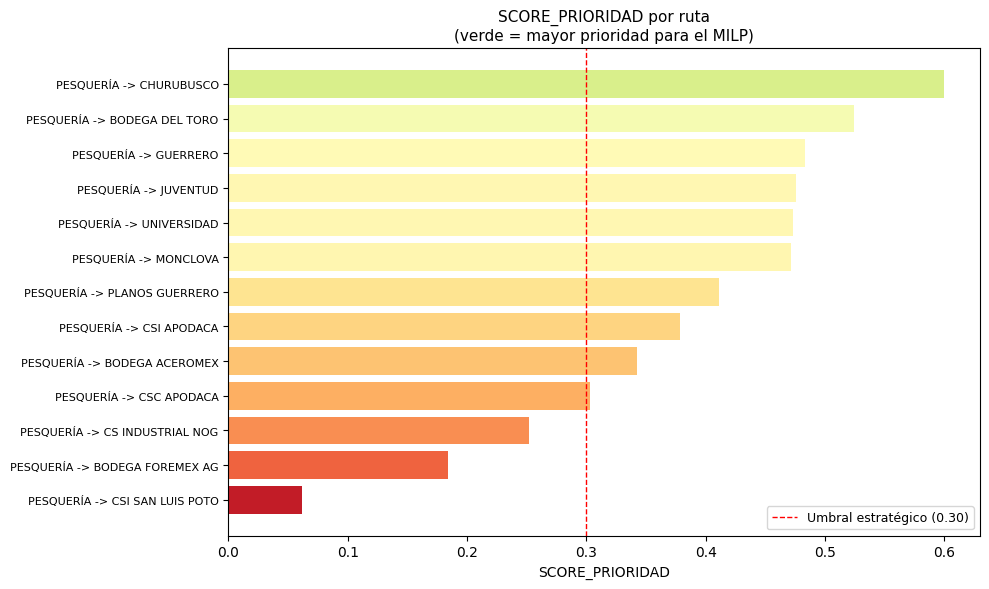

In [ ]:
# ── Visualización de SCORE_PRIORIDAD ──
df_plot = df_modelo.sort_values('SCORE_PRIORIDAD', ascending=True)
colores_barras = plt.cm.RdYlGn(df_plot['SCORE_PRIORIDAD'].values)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(df_plot)), df_plot['SCORE_PRIORIDAD'], color=colores_barras, edgecolor='none')
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['CIRCUITO_OD'].str[:30], fontsize=8)
ax.set_xlabel('SCORE_PRIORIDAD')
ax.set_title('SCORE_PRIORIDAD por ruta\n(verde = mayor prioridad para el MILP)', fontsize=11)
ax.axvline(x=0.30, color='red', linestyle='--', linewidth=1, label='Umbral estratégico (0.30)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('score_prioridad_por_ruta.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.2 Volumen atendido vs no atendido y 11.3 Cobertura por comunidad

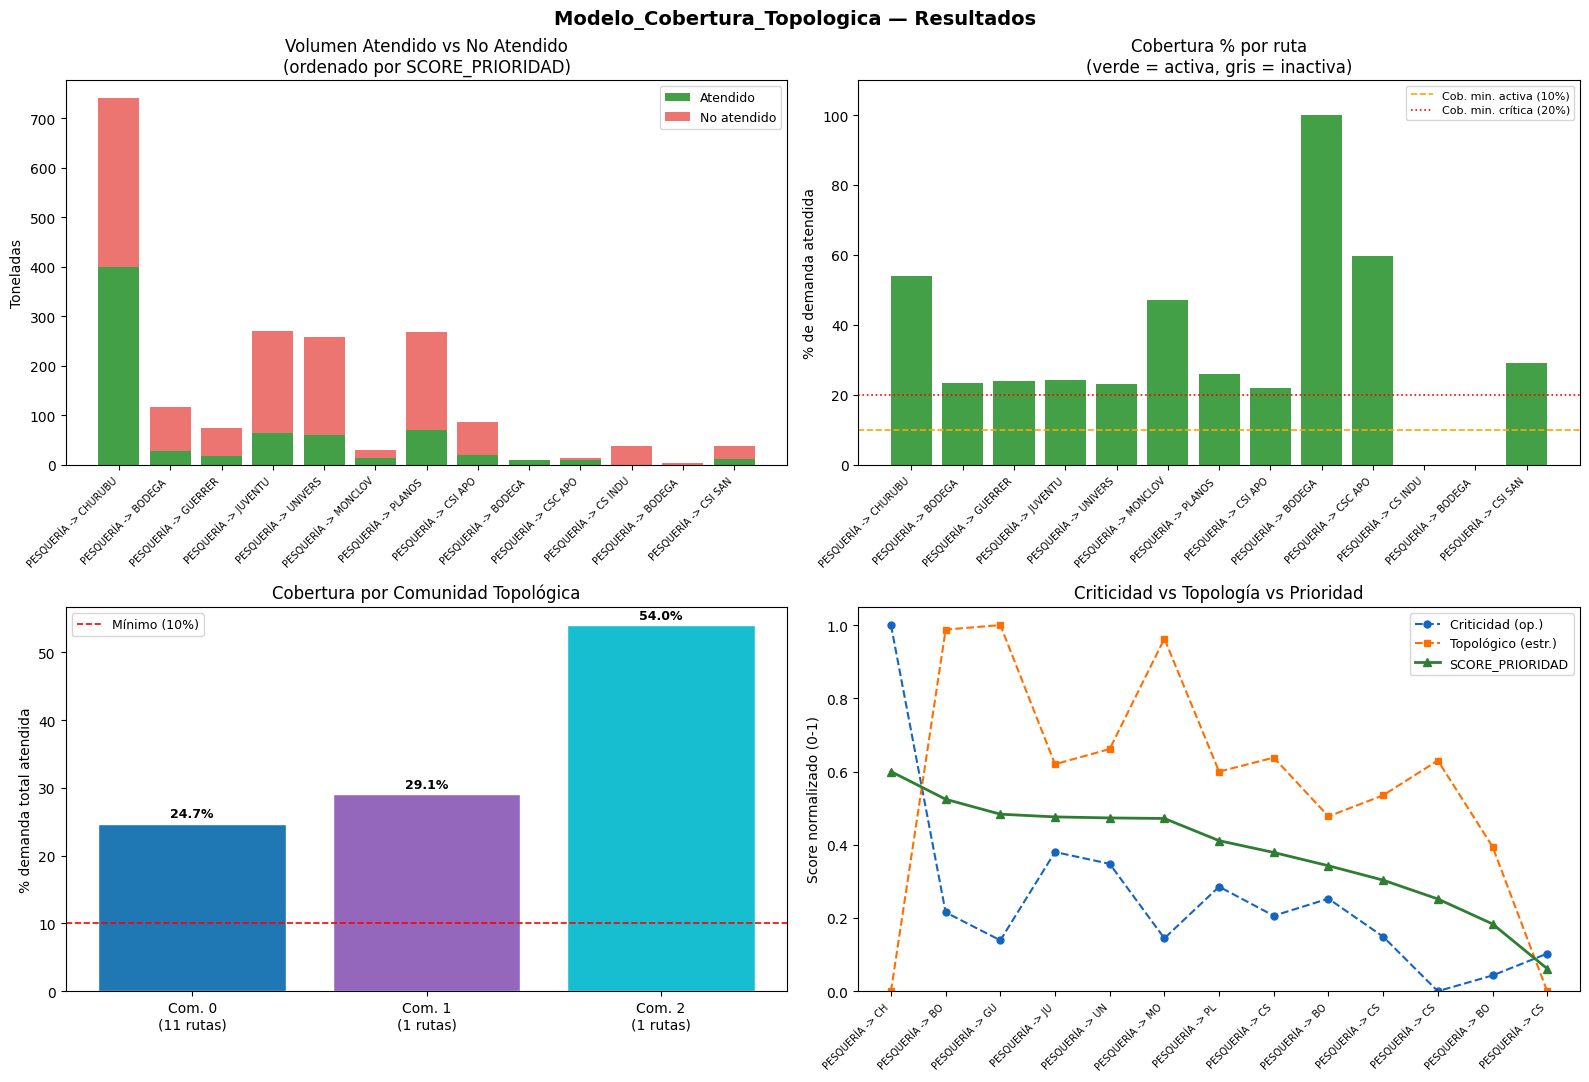

In [ ]:
# ── Visualizaciones de resultados del modelo final ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Modelo_Cobertura_Topologica — Resultados', fontsize=14, fontweight='bold')

df_pv    = df_resultados_cob.sort_values('SCORE_PRIORIDAD', ascending=False)
rutas_lb = df_pv['CIRCUITO_OD'].str[:20]
x_pos    = np.arange(len(rutas_lb))

# 1. Volumen atendido vs no atendido (apilado, ordenado por SCORE_PRIORIDAD)
axes[0, 0].bar(x_pos, df_pv['VOL_ATENDIDO_TON'], color='#43A047', label='Atendido')
axes[0, 0].bar(x_pos, df_pv['VOL_NO_ATENDIDO_TON'],
               bottom=df_pv['VOL_ATENDIDO_TON'], color='#E53935', alpha=0.7, label='No atendido')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(rutas_lb, rotation=45, ha='right', fontsize=7)
axes[0, 0].set_ylabel('Toneladas')
axes[0, 0].set_title('Volumen Atendido vs No Atendido\n(ordenado por SCORE_PRIORIDAD)')
axes[0, 0].legend(fontsize=9)

# 2. Cobertura % por ruta
colores_cob = ['#43A047' if r == 1 else '#90A4AE' for r in df_pv['RUTA_ACTIVA']]
axes[0, 1].bar(x_pos, df_pv['%_ATENDIDO_RUTA'], color=colores_cob, edgecolor='none')
axes[0, 1].axhline(y=cobertura_min_activa * 100, color='orange', linestyle='--', linewidth=1.2,
                   label=f'Cob. min. activa ({int(cobertura_min_activa*100)}%)')
axes[0, 1].axhline(y=cobertura_min_critica * 100, color='red', linestyle=':', linewidth=1.2,
                   label=f'Cob. min. crítica ({int(cobertura_min_critica*100)}%)')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(rutas_lb, rotation=45, ha='right', fontsize=7)
axes[0, 1].set_ylabel('% de demanda atendida')
axes[0, 1].set_title('Cobertura % por ruta\n(verde = activa, gris = inactiva)')
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_ylim(0, 110)

# 3. Cobertura por comunidad topológica
cob_c   = [float(cob_por_comunidad.get(c, 0)) for c in comunidades_ord]
n_rc    = [int((df_resultados_cob['COMUNIDAD_TOPOLOGICA'] == c).sum()) for c in comunidades_ord]
colores_com = plt.cm.tab10(np.linspace(0, 0.9, len(comunidades_ord)))
bars_c  = axes[1, 0].bar(
    [f'Com. {c}\n({n} rutas)' for c, n in zip(comunidades_ord, n_rc)],
    cob_c, color=colores_com, edgecolor='white'
)
axes[1, 0].axhline(y=cobertura_min_comunidad * 100, color='red', linestyle='--', linewidth=1.2,
                   label=f'Mínimo ({int(cobertura_min_comunidad*100)}%)')
for bar, val in zip(bars_c, cob_c):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('% demanda total atendida')
axes[1, 0].set_title('Cobertura por Comunidad Topológica')
axes[1, 0].legend(fontsize=9)

# 4. Criticidad vs Topología vs Prioridad
df_sc = df_resultados_cob.sort_values('SCORE_PRIORIDAD', ascending=False).reset_index(drop=True)
idx_s = np.arange(len(df_sc))
axes[1, 1].plot(idx_s, df_sc['SCORE_CRITICIDAD_NORMALIZADO'], 'o--', color='#1565C0',
                label='Criticidad (op.)', linewidth=1.5, markersize=5)
axes[1, 1].plot(idx_s, df_sc['SCORE_TOPOLOGICO_NORMALIZADO'], 's--', color='#FF6F00',
                label='Topológico (estr.)', linewidth=1.5, markersize=5)
axes[1, 1].plot(idx_s, df_sc['SCORE_PRIORIDAD'], '^-', color='#2E7D32',
                label='SCORE_PRIORIDAD', linewidth=2, markersize=6)
axes[1, 1].set_xticks(idx_s)
axes[1, 1].set_xticklabels(df_sc['CIRCUITO_OD'].str[:15], rotation=45, ha='right', fontsize=7)
axes[1, 1].set_ylabel('Score normalizado (0-1)')
axes[1, 1].set_title('Criticidad vs Topología vs Prioridad')
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('resultados_cobertura_topologica.png', dpi=120, bbox_inches='tight')
plt.show()

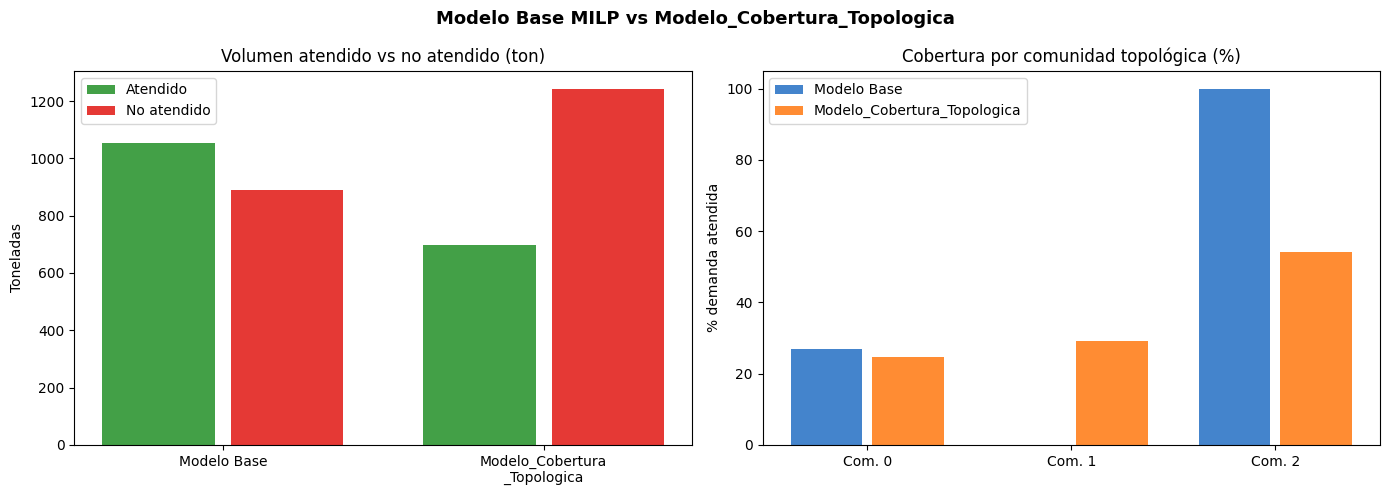

In [ ]:
# ── Comparación visual: Modelo base vs Modelo_Cobertura_Topologica ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Modelo Base MILP vs Modelo_Cobertura_Topologica', fontsize=13, fontweight='bold')

# 1. Volumen atendido vs no atendido por modelo
categorias  = ['Modelo Base', 'Modelo_Cobertura\n_Topologica']
vols_at   = [resumen_base['VOLUMEN_ATENDIDO_TON'],    resumen_cob['VOLUMEN_ATENDIDO_TON']]
vols_noat = [resumen_base['VOLUMEN_NO_ATENDIDO_TON'], resumen_cob['VOLUMEN_NO_ATENDIDO_TON']]
x_p = np.arange(len(categorias))
axes[0].bar(x_p - 0.2, vols_at,   0.35, label='Atendido',     color='#43A047')
axes[0].bar(x_p + 0.2, vols_noat, 0.35, label='No atendido',  color='#E53935')
axes[0].set_xticks(x_p)
axes[0].set_xticklabels(categorias)
axes[0].set_title('Volumen atendido vs no atendido (ton)')
axes[0].set_ylabel('Toneladas')
axes[0].legend()

# 2. Cobertura por comunidad: ambos modelos
x_com = np.arange(len(comunidades_ord))
axes[1].bar(x_com - 0.2, cob_base_c, 0.35, label='Modelo Base', color='#1565C0', alpha=0.8)
axes[1].bar(x_com + 0.2, cob_cob_c,  0.35, label='Modelo_Cobertura_Topologica', color='#FF6F00', alpha=0.8)
axes[1].set_xticks(x_com)
axes[1].set_xticklabels([f'Com. {c}' for c in comunidades_ord])
axes[1].set_title('Cobertura por comunidad topológica (%)')
axes[1].set_ylabel('% demanda atendida')
axes[1].legend()

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Conclusión

El proyecto integra **topología y optimización logística** en un flujo coherente:

1. Se usa **Single Linkage y dendrograma** para crear `COMUNIDAD_TOPOLOGICA`, agrupando rutas con perfiles operativos similares.

2. Se usa **Vietoris-Rips, filtración, diagrama y barcode de persistencia** para identificar estructuras robustas en la red: componentes H0 (comunidades de rutas) y ciclos H1 (huecos estructurales).

3. Con esta información se construye un `SCORE_TOPOLOGICO` que mide la importancia estructural de cada ruta (persistencia H0, betweenness, degree centrality, cercanía al centroide de comunidad).

4. El `SCORE_TOPOLOGICO` se combina con `SCORE_CRITICIDAD` para formar `SCORE_PRIORIDAD`:
   ```
   SCORE_PRIORIDAD = 0.60 * SCORE_CRITICIDAD_NORMALIZADO + 0.40 * SCORE_TOPOLOGICO_NORMALIZADO
   ```

5. Finalmente, el **modelo MILP** (`Modelo_Cobertura_Topologica`) usa ese score para asignar viajes, priorizando rutas importantes tanto operativamente como estructuralmente.
